### Import des modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import missingno as msno
import re
import seaborn as sns
import matplotlib.pyplot as plt
import json

### Lecture du fichier Seattle CSV

In [2]:
building_consumption = pd.read_csv("./data/2016_Building_Energy_Benchmarking.csv")

### On regarde comment un batiment est défini dans ce jeu de données 

In [3]:
pd.set_option("display.max_columns",None ) # affiche toutes les colonnes
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


### Affichage dictionnaire de données

In [4]:
df_xls= pd.read_excel ("./data/dico_seattle_2016.xlsx")
display(df_xls)

,N°,Nom de la Colonne,Catégorie,Type Python,Manquants (Global),Description & Signification Métier
0,1,OSEBuildingID,Identifiant,int64,0 (0.0%),Identifiant unique attribué à chaque bâtiment ...
1,2,DataYear,Spatio-temporel,int64,0 (0.0%),Année à laquelle s'appliquent les données de b...
2,3,BuildingType,Typologie,object,0 (0.0%),Catégorie administrative globale du bâtiment (...
3,4,PrimaryPropertyType,Typologie,object,0 (0.0%),Type d'usage principal du bâtiment de manière ...
4,5,PropertyName,Identifiant,object,0 (0.0%),Nom officiel ou commercial du bâtiment.
5,6,Address,Identifiant,object,0 (0.0%),Adresse postale du bâtiment.
6,7,City,Spatio-temporel,object,0 (0.0%),Ville où se situe le bâtiment (Seattle).
7,8,State,Spatio-temporel,object,0 (0.0%),État où se situe le bâtiment (WA).
8,9,ZipCode,Spatio-temporel,float64,16 (0.5%),Code postal du bâtiment.
9,10,TaxParcelIdentificationNumber,Identifiant,object,0 (0.0%),Numéro de parcelle cadastrale / d'imposition f...


On analyse les colonnes ainsi que leur type 

In [5]:
building_consumption.info()

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

# info du CSV

In [6]:
print(f"Nombre de bâtiments total : {len(building_consumption)}")
print (f"Nombre de colonnes : {len(building_consumption.columns)}")

Nombre de bâtiments total : 3376
Nombre de colonnes : 46


### On s'intéresse de près à la consommation et aux émissions des bâtiments non destinés à l’habitation.

In [7]:
building_consumption["PrimaryPropertyType"].unique().tolist()

['Hotel',
 'Other',
 'Mid-Rise Multifamily',
 'Mixed Use Property',
 'K-12 School',
 'University',
 'Small- and Mid-Sized Office',
 'Self-Storage Facility',
 'Warehouse',
 'Large Office',
 'Senior Care Community',
 'Medical Office',
 'Retail Store',
 'Hospital',
 'Residence Hall',
 'Distribution Center',
 'Worship Facility',
 'Low-Rise Multifamily',
 'Supermarket / Grocery Store',
 'Laboratory',
 'Refrigerated Warehouse',
 'Restaurant',
 'High-Rise Multifamily',
 'Office']

In [8]:
building_consumption["BuildingType"].unique().tolist()

['NonResidential',
 'Nonresidential COS',
 'Multifamily MR (5-9)',
 'SPS-District K-12',
 'Campus',
 'Multifamily LR (1-4)',
 'Multifamily HR (10+)',
 'Nonresidential WA']

### Filtrage des lignes qui ne contiennent 'Multifamily' ni dans BuildingType ni dans PrimaryPropertyType

In [9]:

print(f"Nombre de bâtiments avant supression : {len(building_consumption)}")
building_consumption = building_consumption[
    ~building_consumption["BuildingType"].str.lower().str.contains("multifamily", na=False)
    & ~building_consumption["PrimaryPropertyType"].str.lower().str.contains("multifamily", na=False)]
print(f"Nombre de bâtiments non résidentiels conservés : {len(building_consumption)}")
print (f"Nombre de colonnes : {len(building_consumption.columns)}")

Nombre de bâtiments avant supression : 3376
Nombre de bâtiments non résidentiels conservés : 1665
Nombre de colonnes : 46


### Proportion des NaN dans le data frame

<Axes: title={'center': '% NaN par variable du data frame'}, ylabel='None'>

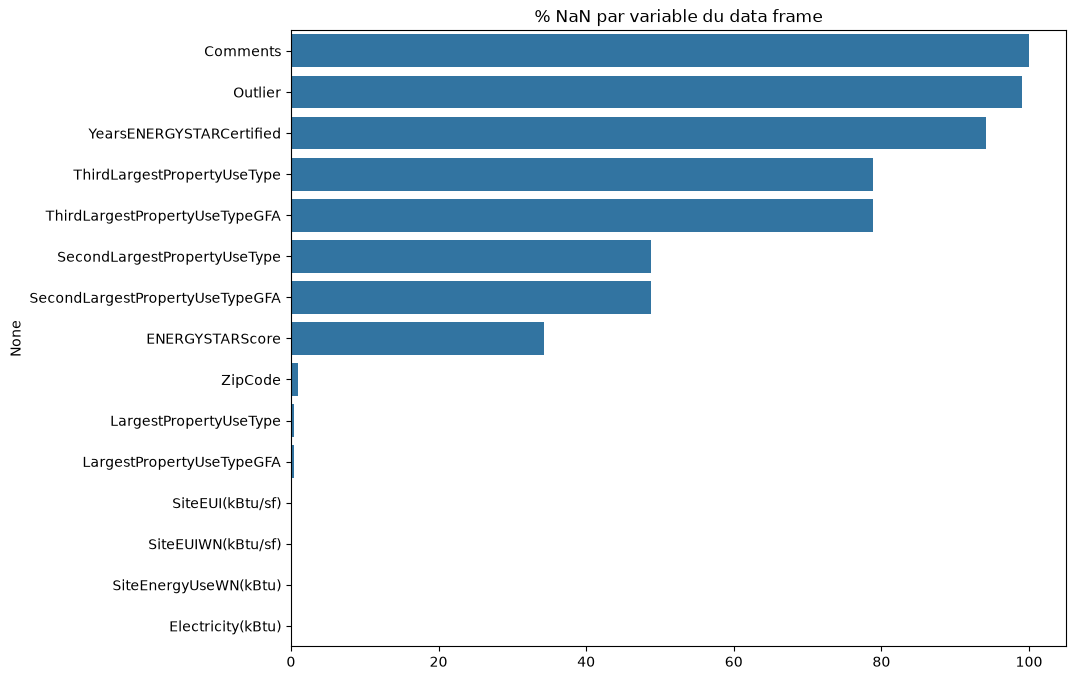

In [10]:
df_nan = building_consumption.isna().sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(10,8))
plt.title('% NaN par variable du data frame')
sns.barplot(x=df_nan.values/building_consumption.shape[0]*100, y=df_nan.index)

### Supression des lignes outlier non Nan données aberrantes définies dans  building_consumption

In [11]:
nbligne_avant = len(building_consumption)
print (f"Nombre de colonnes avant : {len(building_consumption.columns)}")
building_consumption = building_consumption[building_consumption['Outlier'].isna()].reset_index(drop=True)

print(f"Nombre de lignes building_consumption : {len(building_consumption)}")
print(f"Nombre de lignes building_consumption supprimées : {nbligne_avant -len(building_consumption)}")

Nombre de colonnes avant : 46
Nombre de lignes building_consumption : 1649
Nombre de lignes building_consumption supprimées : 16


In [12]:
# supression de la colonne outlier
building_consumption = building_consumption.drop (columns=['Outlier'], errors='ignore')
print (f"Nombre de colonnes après : {len(building_consumption.columns)}")

Nombre de colonnes après : 45


### Recherche si il y a des NaN dans la colonne TotalGHGEmissions

In [13]:
print (building_consumption.loc[building_consumption["TotalGHGEmissions"].isna(), "TotalGHGEmissions"])

564    NaN
1406   NaN
Name: TotalGHGEmissions, dtype: float64


### Suppression des lignes NaN 

In [14]:
building_consumption = building_consumption[~building_consumption['TotalGHGEmissions'].isna()].reset_index(drop=True)
print(f"Nombre de bâtiments non résidentiels conservés après : {len(building_consumption)}")

Nombre de bâtiments non résidentiels conservés après : 1647


### Recherche si il y a 0 dans TotalGHGEmissions

In [15]:
display ( building_consumption[ building_consumption["TotalGHGEmissions"]==0])

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
27,34,2016,SPS-District K-12,K-12 School,Meany Building,301/300 21st Ave. E.,Seattle,WA,98112.0,0688000090,3,Central,47.62266,-122.30547,1955,1.0,1,126351,0,126351,K-12 School,K-12 School,126351.0,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,NaN,Missing Data,0.0,0.0
151,242,2016,SPS-District K-12,K-12 School,Olympic View Elementary,504 N.E. 95th St.,Seattle,WA,98115.0,5100404840,5,NORTH,47.69823,-122.32126,1989,1.0,2,52792,0,52792,K-12 School,K-12 School,55480.0,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,NaN,Missing Data,0.0,0.0
297,435,2016,NonResidential,Other,Washington State Convention Center,705 Pike St,Seattle,WA,98101.0,1978200105,7,DOWNTOWN,47.61195,-122.33167,1990,1.0,6,1400000,0,1400000,"Convention Center, Parking",Convention Center,1072000.0,Parking,686750.0,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,NaN,Non-Compliant,0.0,0.0
500,700,2016,NonResidential,Supermarket / Grocery Store,IUC- Whole Foods Interbay,2001 15th Avenue West,Seattle,WA,98119.0,7666201460,7,MAGNOLIA / QUEEN ANNE,47.63718,-122.37734,2008,1.0,1,57176,0,57176,"Personal Services (Health/Beauty, Dry Cleaning...",Supermarket/Grocery Store,39500.0,Retail Store,15000.0,"Personal Services (Health/Beauty, Dry Cleaning...",5500.0,NaN,31.0,208.800003,214.100006,0.0,0.0,12525174.0,12843856.0,0.0,0.0,0.0,0.0,0.0,False,NaN,Compliant,0.0,0.0
661,19776,2016,NonResidential,Other,Welcome Home Society - PriceCo,13537 Aurora Ave N,Seattle,WA,98133.0,0164000020,5,NORTHWEST,47.72777,-122.34503,2002,1.0,1,29924,0,29924,Other - Education,Other - Education,29924.0,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,NaN,Missing Data,0.0,0.0
931,21616,2016,SPS-District K-12,K-12 School,Olympic Hills Elementary,13018 20th Ave. N.E.,Seattle,WA,98125.0,2126049041,5,NORTH,47.72369,-122.30676,1954,1.0,1,42292,0,42292,K-12 School,K-12 School,43188.0,NaN,NaN,NaN,NaN,NaN,100.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,NaN,Error - Correct Default Data,0.0,0.0


In [16]:
building_consumption = building_consumption[ building_consumption["TotalGHGEmissions"]> 0]
print(f"Nombre de bâtiments non résidentiels conservés après : {len(building_consumption)}")

Nombre de bâtiments non résidentiels conservés après : 1640


### Distribution avec échelle log sur X

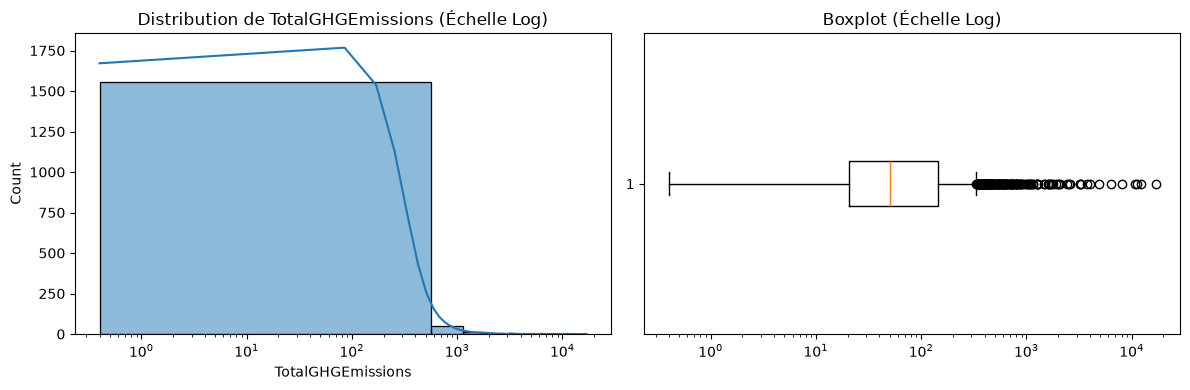

Lignes à supprimées car outliers extrêmes : 97
Nombre de bâtiments non résidentiels conservés après : 1543


In [17]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogramme
sns.histplot(building_consumption["TotalGHGEmissions"], kde=True, bins=30, ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_title("Distribution de TotalGHGEmissions (Échelle Log)")



axes[1].boxplot( x=building_consumption["TotalGHGEmissions"] , orientation ="horizontal")
axes[1].set_xscale("log")
axes[1].set_title("Boxplot (Échelle Log)")
axes[1].set_xlabel

plt.tight_layout()
plt.show()

# Démarche des outliers extrêmes (méthode de l'IQR : écart interquantile)
Q1 = building_consumption["TotalGHGEmissions"].quantile(0.25)
Q3 = building_consumption["TotalGHGEmissions"].quantile(0.75)
IQR = Q3 - Q1

# Seuil haut et seuil bas (3 * IQR pour filtrer uniquement les valeurs très extrêmes)
seuil_haut = Q3 + 3 * IQR

seuil_bas = Q3 - 3 * IQR

# Filtrage
df_clean = building_consumption[(building_consumption["TotalGHGEmissions"] >= seuil_bas) & (building_consumption["TotalGHGEmissions"] <= seuil_haut)].copy()
print(f"Lignes à supprimées car outliers extrêmes : {len(building_consumption) - len(df_clean)}")
building_consumption = df_clean.copy()
print(f"Nombre de bâtiments non résidentiels conservés après : {len(df_clean)}")

### Matrice du data frame  (vue globale non résidentiel)

<Axes: >

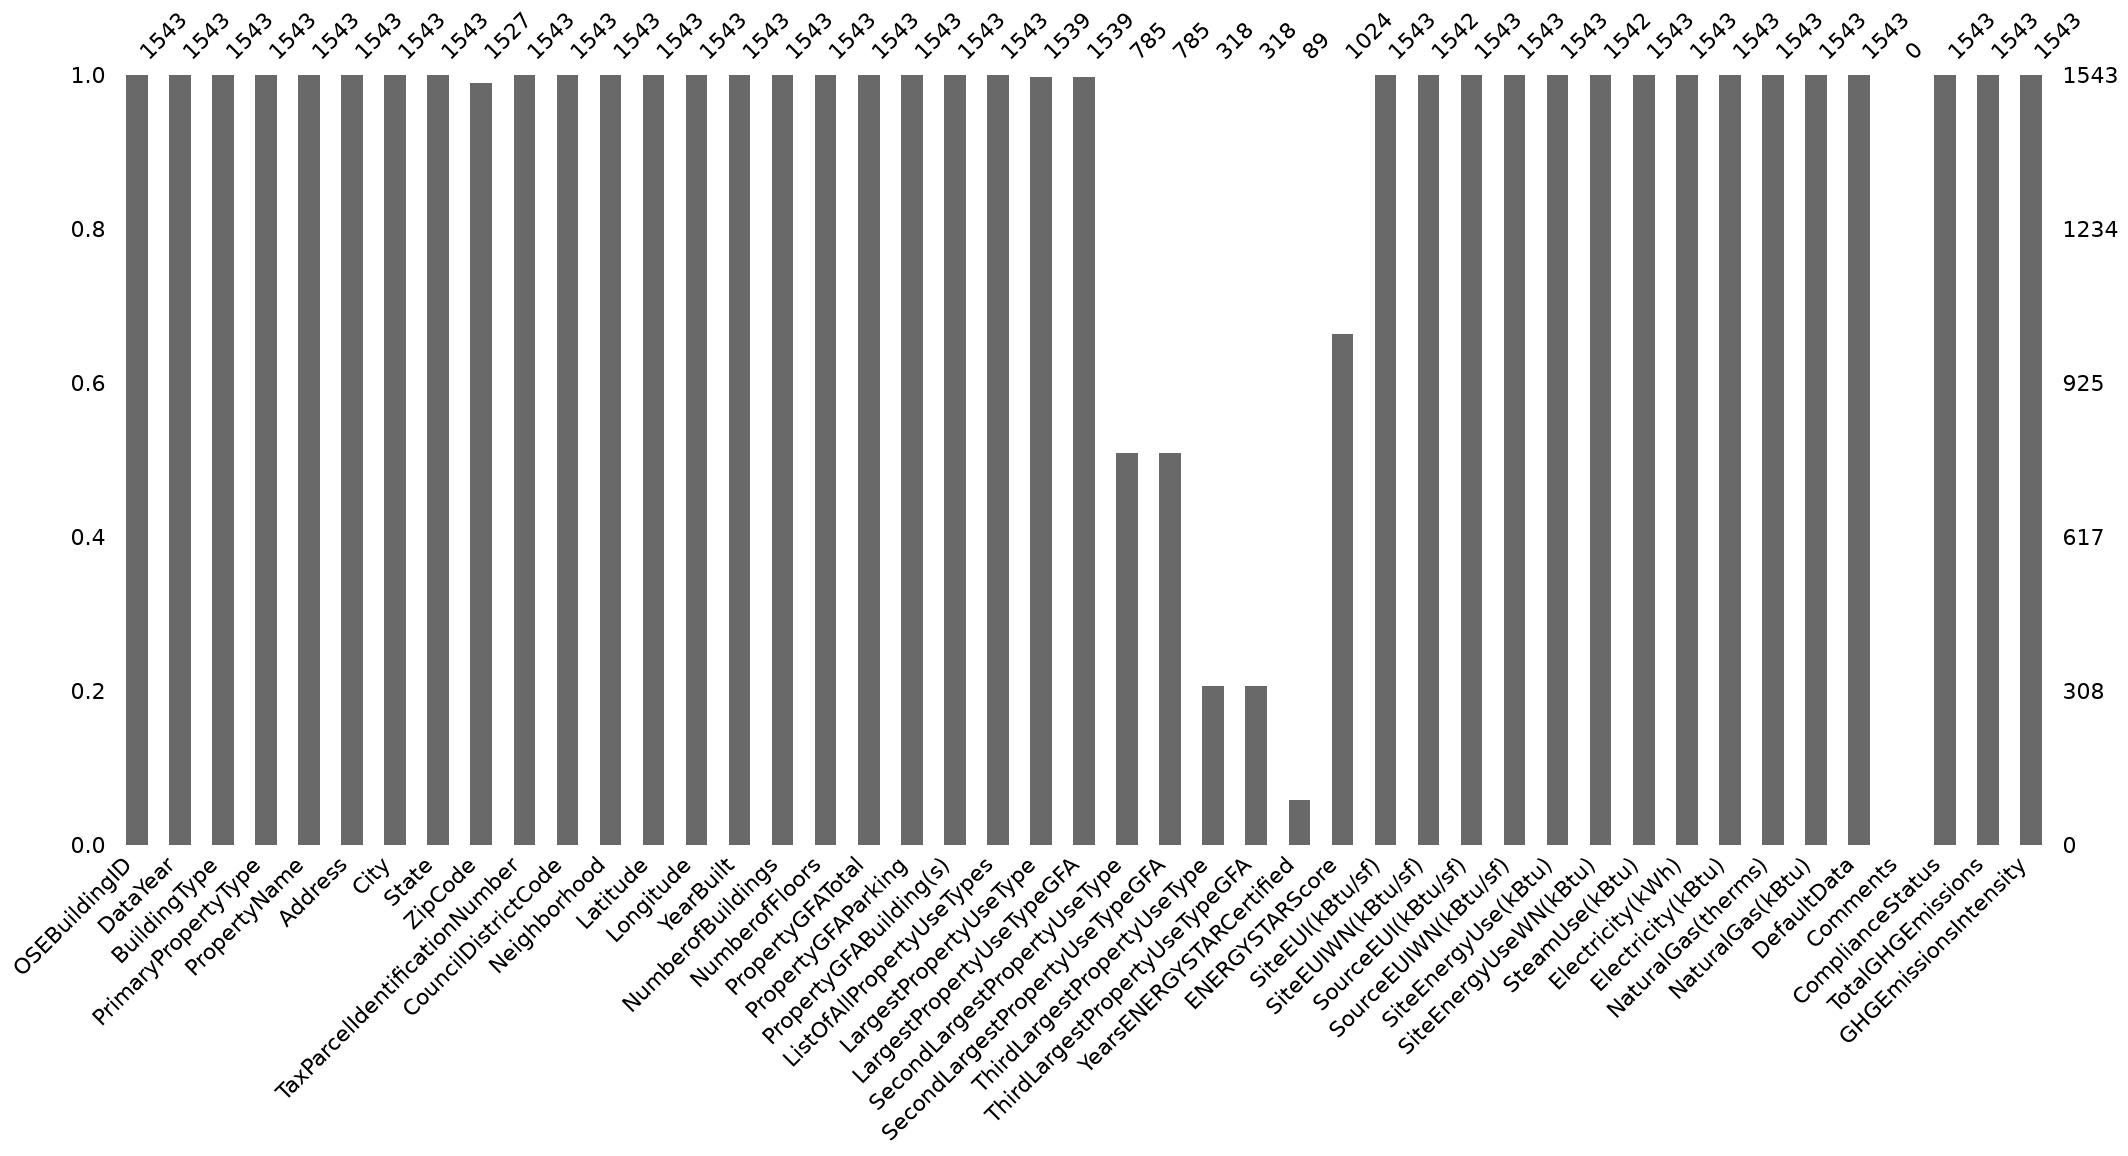

In [18]:
msno.bar(building_consumption)

### on vérifie les doublons dans la colonne OSEBuildingID

In [19]:
# valeur True si il y a au moins un doublon sinon False
verif_doublon = building_consumption["OSEBuildingID"].duplicated().any()
print ( verif_doublon )

False


### Nettoyage des colonnes de type administratif et celles avec des valeurs manquantes
##### ( on ne garde que la latitude et longitude qui sont plus précis et moins 
##### sujet au modification administrative )

In [20]:
df_non_residentiel = building_consumption.copy() # copy avant nettoyage

print (f"Nombre de colonnes avant : {len(df_non_residentiel.columns)}")

#on supprime la colonne Comments qui est vide
df_non_residentiel  = df_non_residentiel.drop(columns=['Comments'], errors='ignore') # colonne vide

df_non_residentiel = df_non_residentiel.drop(columns=['City'], errors='ignore') # ville seattle
df_non_residentiel = df_non_residentiel.drop (columns=['State'], errors='ignore') # etat
df_non_residentiel = df_non_residentiel.drop (columns=['OSEBuildingID'], errors='ignore') # id du fichier

df_non_residentiel = df_non_residentiel.drop (columns=['PropertyName'], errors='ignore') # nom de la propriété
df_non_residentiel = df_non_residentiel.drop (columns=['Address'], errors='ignore') # adresse de la propriété
df_non_residentiel = df_non_residentiel.drop (columns=['ZipCode'], errors='ignore') # code postal
df_non_residentiel = df_non_residentiel.drop (columns=['CouncilDistrictCode'], errors='ignore') # numéro du district
df_non_residentiel = df_non_residentiel.drop (columns=['Neighborhood'], errors='ignore') # nom du quartier
df_non_residentiel = df_non_residentiel.drop (columns=['TaxParcelIdentificationNumber'], errors='ignore') #Numréro de parcelle

df_non_residentiel = df_non_residentiel.drop (columns=['YearsENERGYSTARCertified'], errors='ignore') # beaucoup de termes manquant


#  intensité des émissions 
df_non_residentiel = df_non_residentiel.drop (columns=['GHGEmissionsIntensity'], errors='ignore')

print (f"Nombre de colonnes après : {len(df_non_residentiel.columns)}")

print(f"Nombre de lignes df_non_residentiel : {len(df_non_residentiel)}")



Nombre de colonnes avant : 45
Nombre de colonnes après : 33
Nombre de lignes df_non_residentiel : 1543


In [21]:
df_non_residentiel.info()

<class 'pandas.DataFrame'>
Index: 1543 entries, 0 to 1646
Data columns (total 33 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   DataYear                         1543 non-null   int64  
 1   BuildingType                     1543 non-null   str    
 2   PrimaryPropertyType              1543 non-null   str    
 3   Latitude                         1543 non-null   float64
 4   Longitude                        1543 non-null   float64
 5   YearBuilt                        1543 non-null   int64  
 6   NumberofBuildings                1543 non-null   float64
 7   NumberofFloors                   1543 non-null   int64  
 8   PropertyGFATotal                 1543 non-null   int64  
 9   PropertyGFAParking               1543 non-null   int64  
 10  PropertyGFABuilding(s)           1543 non-null   int64  
 11  ListOfAllPropertyUseTypes        1543 non-null   str    
 12  LargestPropertyUseType           153

### BoxPlot par type de batiments

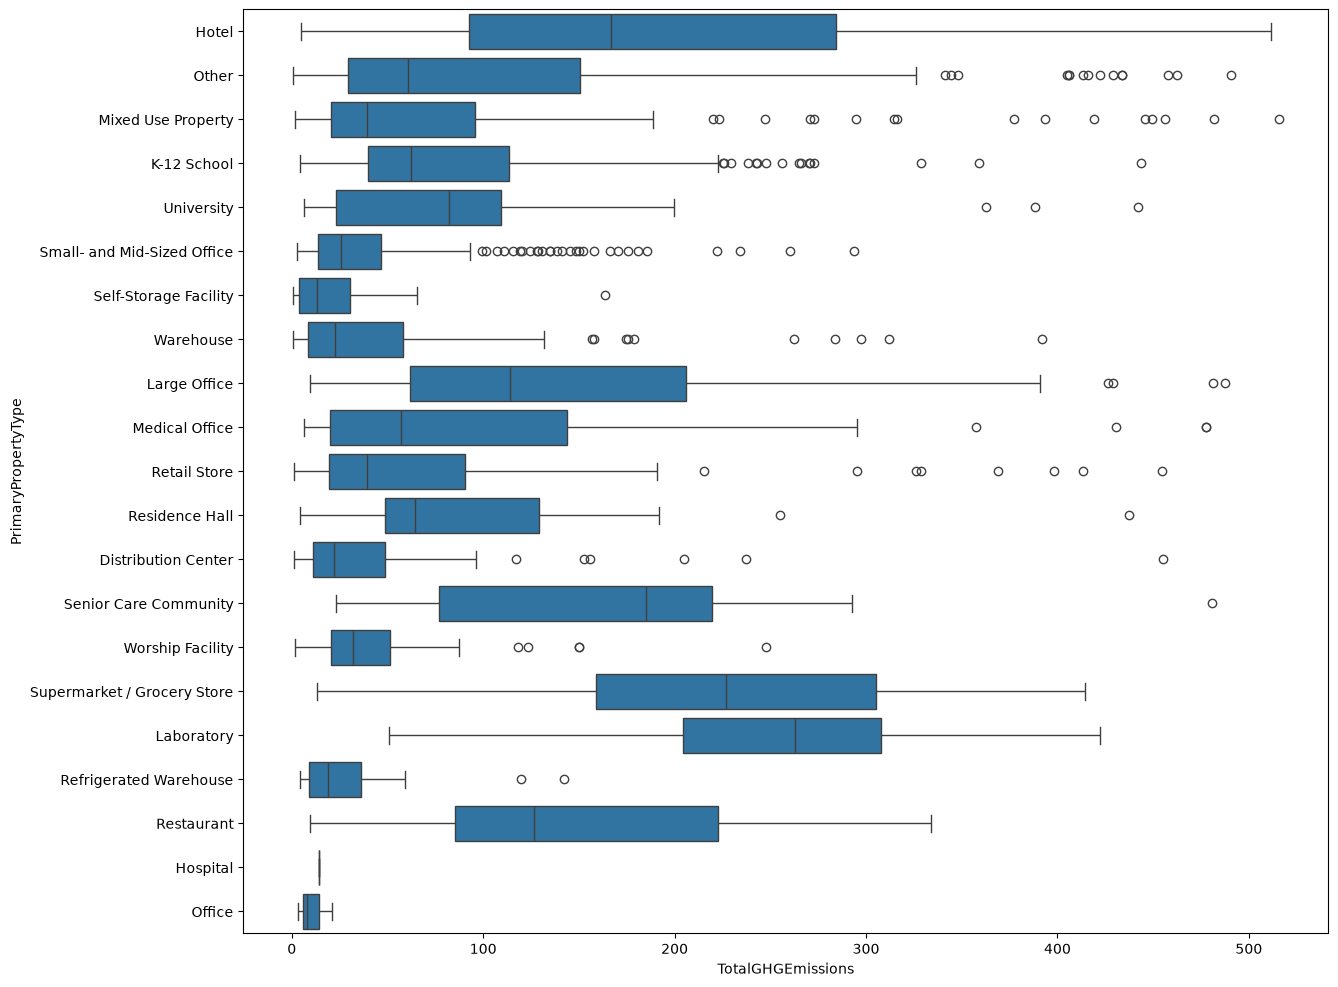

In [22]:
plt.figure(figsize=(14,12))
fig.suptitle("Boxplot  TotalGHGEmissions / PrimaryPropertyType", fontsize=14, y=0.95)

sns.boxplot(x='TotalGHGEmissions',y='PrimaryPropertyType',data=df_non_residentiel)
plt.show()

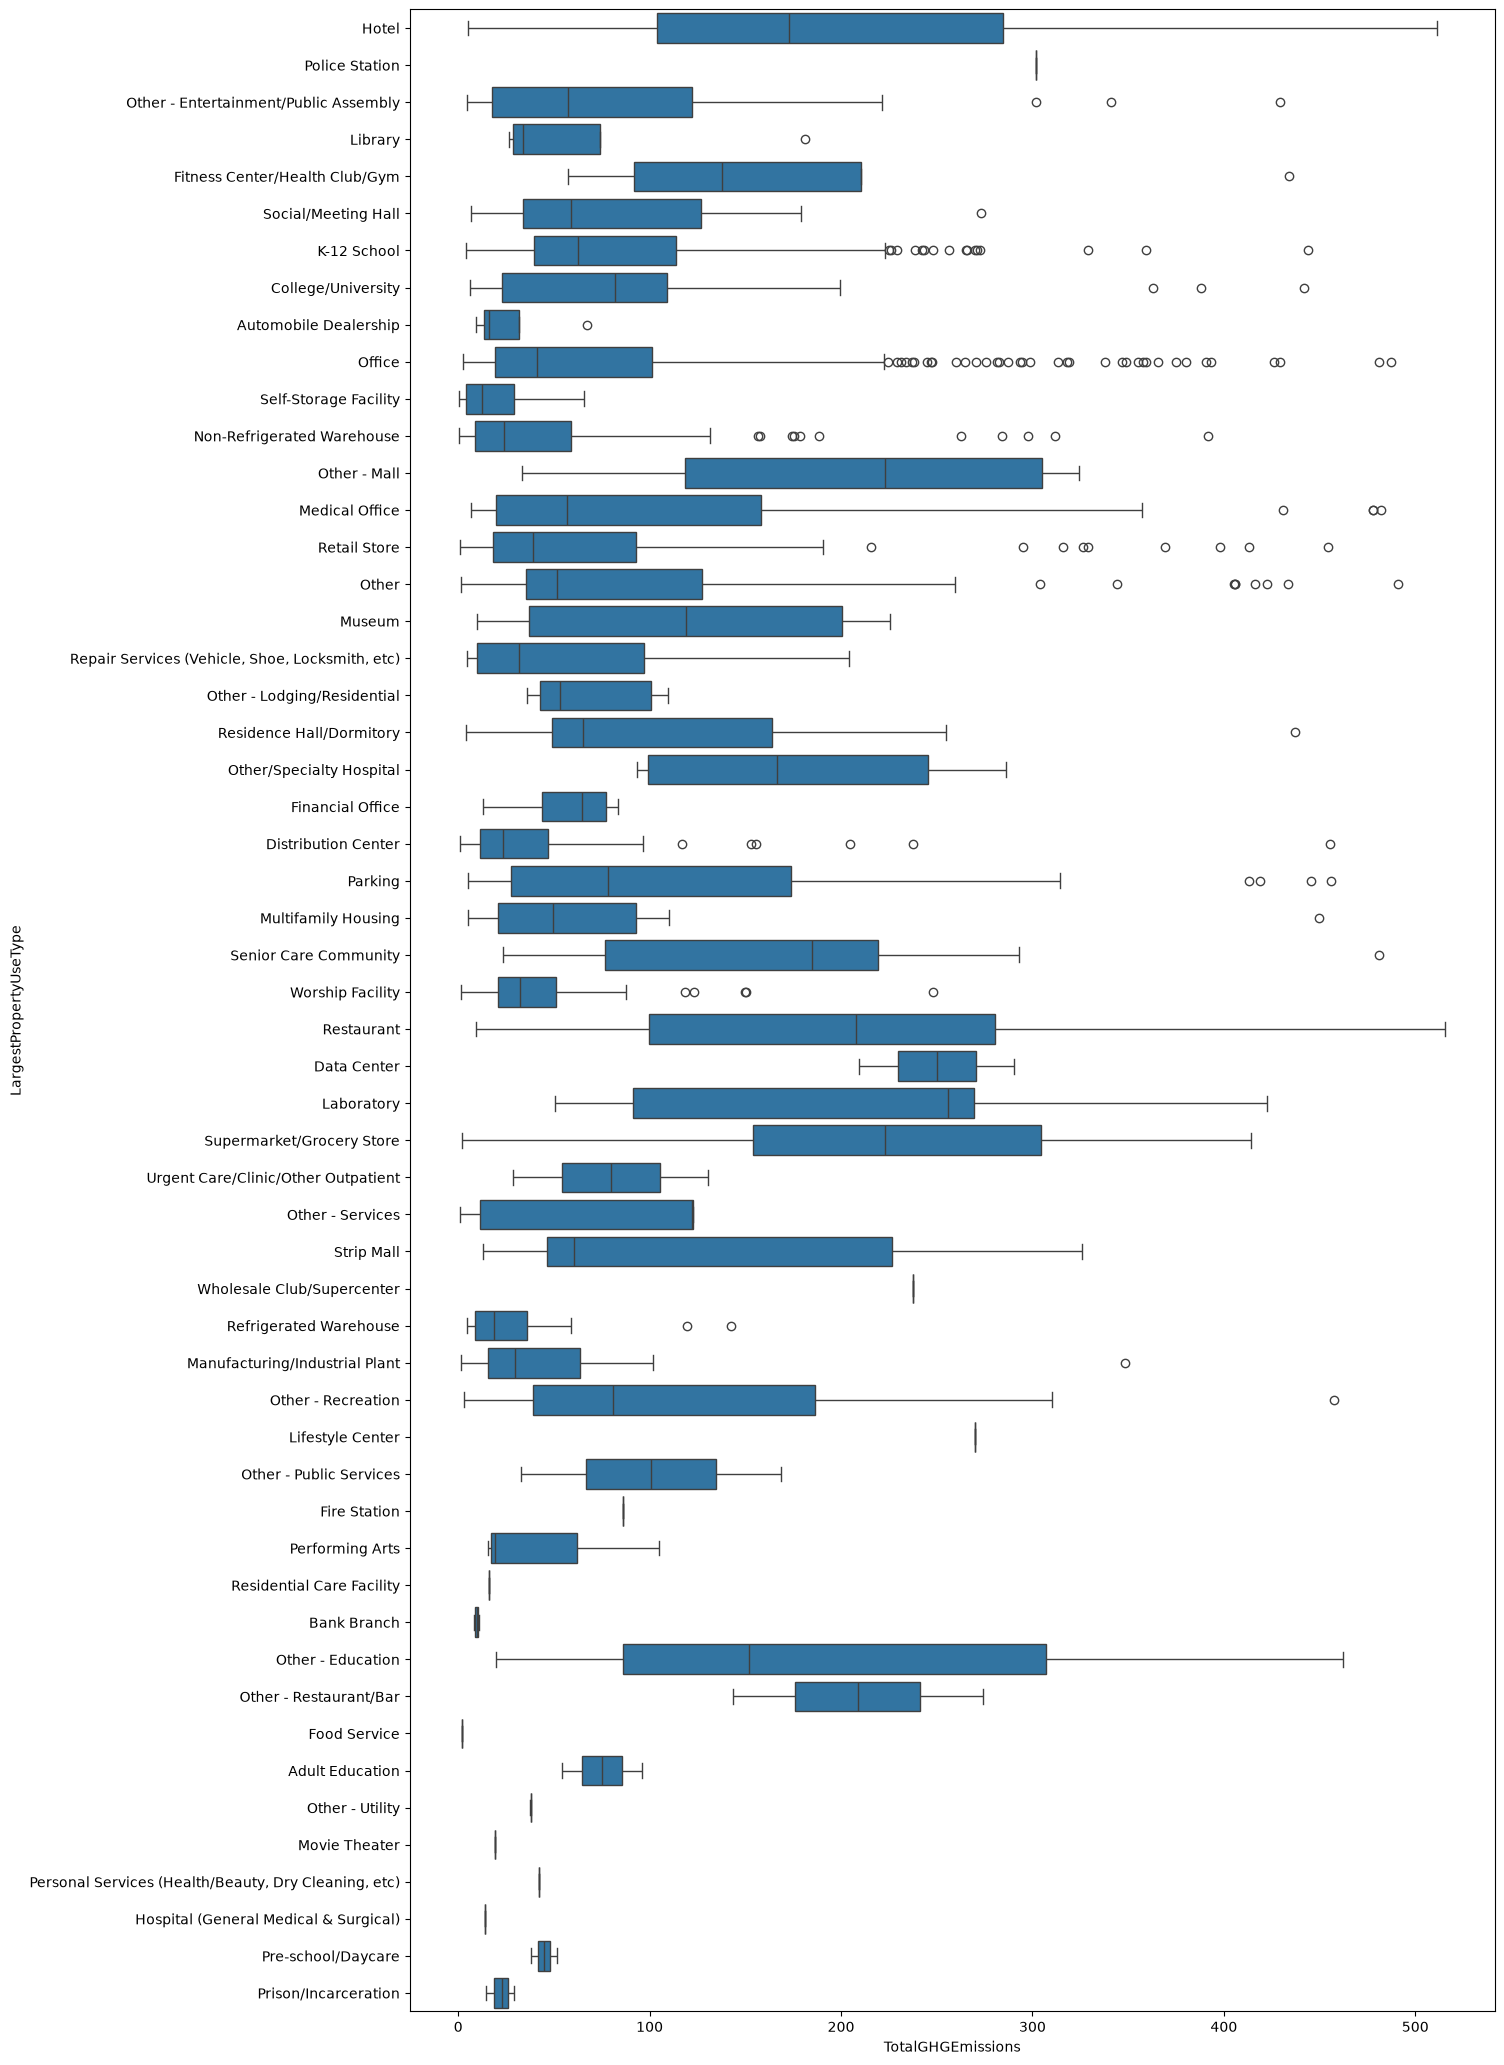

In [23]:
plt.figure(figsize=(14,26))
fig.suptitle("Boxplot  TotalGHGEmissions / LargestPropertyUseType", fontsize=14, y=0.95)

sns.boxplot(x='TotalGHGEmissions',y='LargestPropertyUseType',data=df_non_residentiel)
plt.show()

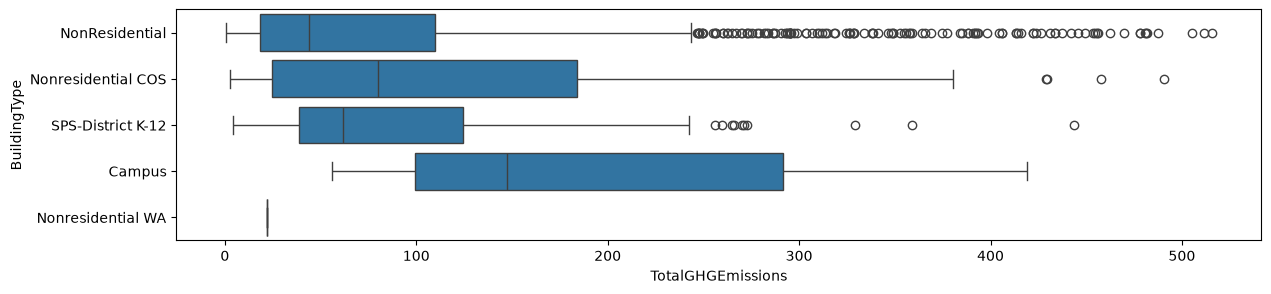

In [24]:
plt.figure(figsize=(14,3))
fig.suptitle("Boxplot  TotalGHGEmissions / BuildingType", fontsize=14, y=0.95)

sns.boxplot(x='TotalGHGEmissions',y='BuildingType',data=df_non_residentiel)
plt.show()

# Evaluation de la colonne : ENERGYSTARScore

In [25]:
# ajout colonne binaire (1 si manquant, 0 si présent) / gestion des valeurs non renseignées
print (f"Nombre de colonnes avant : {len(df_non_residentiel.columns)}")
df_non_residentiel["ENERGYSTARScoreIsMissing"] = (
    df_non_residentiel["ENERGYSTARScore"].isna().astype(int)
)
print (f"Nombre de colonnes après un rajout  : {len(df_non_residentiel.columns)}")

Nombre de colonnes avant : 33
Nombre de colonnes après un rajout  : 34


In [26]:
# Affiche les  premières lignes avec le score d'origine et la nouvelle colonne
df_non_residentiel[["ENERGYSTARScore", "ENERGYSTARScoreIsMissing"]].head(10)


,ENERGYSTARScore,ENERGYSTARScoreIsMissing
0,60.0,0
1,61.0,0
3,56.0,0
4,75.0,0
5,NaN,1
6,27.0,0
7,NaN,1
8,43.0,0
11,48.0,0
13,35.0,0


In [27]:
# Maintenant on calcule  la médiane par rapport à la catégorie : primary_property_type pour ne pas fausser la moyenne 
# des NaN dans ENERGYSTARScore
df_non_residentiel["ENERGYSTARScore"] = df_non_residentiel.groupby("BuildingType")[
    "ENERGYSTARScore"
].transform(lambda x: x.fillna(x.median()))
df_non_residentiel[["ENERGYSTARScore", "ENERGYSTARScoreIsMissing"]].head(10)

,ENERGYSTARScore,ENERGYSTARScoreIsMissing
0,60.0,0
1,61.0,0
3,56.0,0
4,75.0,0
5,69.0,1
6,27.0,0
7,71.0,1
8,43.0,0
11,48.0,0
13,35.0,0


In [28]:
# on verifie plus de NaN
print (df_non_residentiel["ENERGYSTARScore"].isna().sum() )


1


In [29]:
df_nan = df_non_residentiel[df_non_residentiel["ENERGYSTARScore"].isna()]
df_nan.head()

,DataYear,BuildingType,PrimaryPropertyType,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions,ENERGYSTARScoreIsMissing
1630,2016,Nonresidential WA,University,47.66127,-122.31256,1962,1.0,1,68072,0,68072,College/University,College/University,68916.0,NaN,NaN,NaN,NaN,NaN,46.200001,46.200001,144.899994,144.899994,3180819.25,3180819.25,0.0,932244.6875,3180819.0,0.0,0.0,False,Compliant,22.17,1


In [30]:
df_non_residentiel["ENERGYSTARScore"] = df_non_residentiel.groupby("PrimaryPropertyType")[
    "ENERGYSTARScore"
].transform(lambda x: x.fillna(x.median()))

In [31]:
# on verifie plus de NaN
print (df_non_residentiel["ENERGYSTARScore"].isna().sum() )

0


# Evaluation de la colonne  ComplianceStatus

In [32]:

# Masque pour les lignes NON-COMPLIANT et COMPLIANT

mask_non_compliant = df_non_residentiel["ComplianceStatus"] != "Compliant"
anomalies_non_compliant = df_non_residentiel[mask_non_compliant ]


mask_compliant = df_non_residentiel["ComplianceStatus"] == "Compliant"
anomalies_compliant = df_non_residentiel[mask_compliant]

msk_defaultData = df_non_residentiel["DefaultData"] == True 

anomalies_defaultdata = df_non_residentiel [msk_defaultData]

anomalies_defaultdata_compliant = df_non_residentiel [ (msk_defaultData) & (mask_compliant )]
anomalies_defaultdata_non_compliant = df_non_residentiel [ (df_non_residentiel["DefaultData"] == True ) & (mask_non_compliant )]
anomalies_defaultdata_false_non_compliant = df_non_residentiel [ (df_non_residentiel["DefaultData"] != True ) & (mask_non_compliant )]



nb_anomalies_non_compliant = len(anomalies_non_compliant)
nb_anomalies_compliant = len(anomalies_compliant)
nb_anomalies_DefaultData = len (anomalies_defaultdata )

anomalies_non_compliant_total = df_non_residentiel [ (df_non_residentiel["TotalGHGEmissions"] >0 ) & (mask_non_compliant )]

nb_anomalies_DefaultData_compliant = len (anomalies_defaultdata_compliant )
nb_anomalies_DefaultData_non_compliant = len (anomalies_defaultdata_non_compliant )
nb_anomalies_DefaultData_false_non_compliant = len (anomalies_defaultdata_false_non_compliant )
nb_anomalies_non_compliant_total = len (anomalies_non_compliant_total)

print(f"Anomalies sur les non-compliant : {nb_anomalies_non_compliant}")
print(f"Anomalies sur les compliant     : {nb_anomalies_compliant}")

print(f"Anomalies sur les defaultData     : {nb_anomalies_DefaultData}")
print(f"Anomalies sur les defaultData  & compliant   : {nb_anomalies_DefaultData_compliant}")
print(f"Anomalies sur les defaultData true  & non compliant   : {nb_anomalies_DefaultData_non_compliant}")
print(f"Anomalies sur les defaultData false & non compliant   : {nb_anomalies_DefaultData_false_non_compliant}")

print (f"non compliant & TotalGHGEmissions {nb_anomalies_non_compliant_total} ")




Anomalies sur les non-compliant : 96
Anomalies sur les compliant     : 1447
Anomalies sur les defaultData     : 85
Anomalies sur les defaultData  & compliant   : 0
Anomalies sur les defaultData true  & non compliant   : 85
Anomalies sur les defaultData false & non compliant   : 11
non compliant & TotalGHGEmissions 96 


In [33]:
print ("On remarque que les defaultData sont compris dans les non-compliant , ceci seront retirés dans notre data frame df_esti ")

On remarque que les defaultData sont compris dans les non-compliant , ceci seront retirés dans notre data frame df_esti 


In [34]:
df_non_residentiel = df_non_residentiel.drop (columns=['DefaultData'], errors='ignore')

In [35]:



print (f"Nombre de colonnes après : {len(df_non_residentiel.columns)}")

print(f"Nombre de lignes df_non_residentiel : {len(df_non_residentiel)}")

Nombre de colonnes après : 33
Nombre de lignes df_non_residentiel : 1543


### Répartition du type de batiments

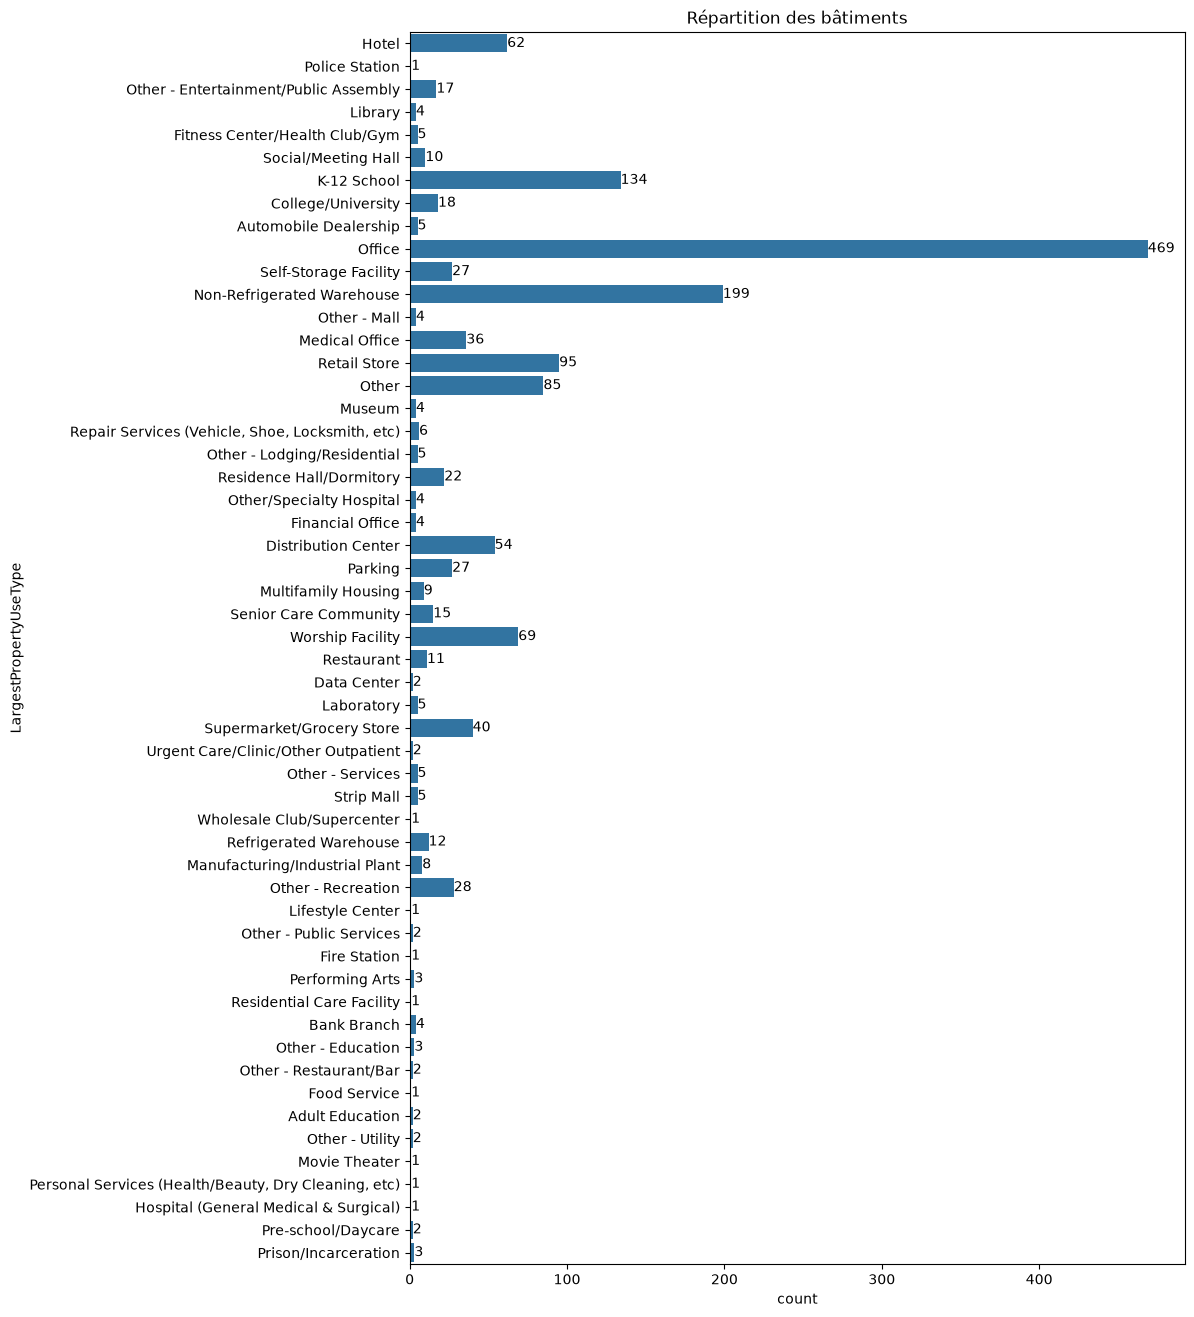

In [36]:
plt.figure(figsize=(10,16))
ax1 = sns.countplot(y='LargestPropertyUseType', data=df_non_residentiel)
ax1.bar_label(ax1.containers[0])
plt.title('Répartition des bâtiments')
plt.show()

### dans le graphe on a une large majorité de batiment de type office

### Graphe des années de construction

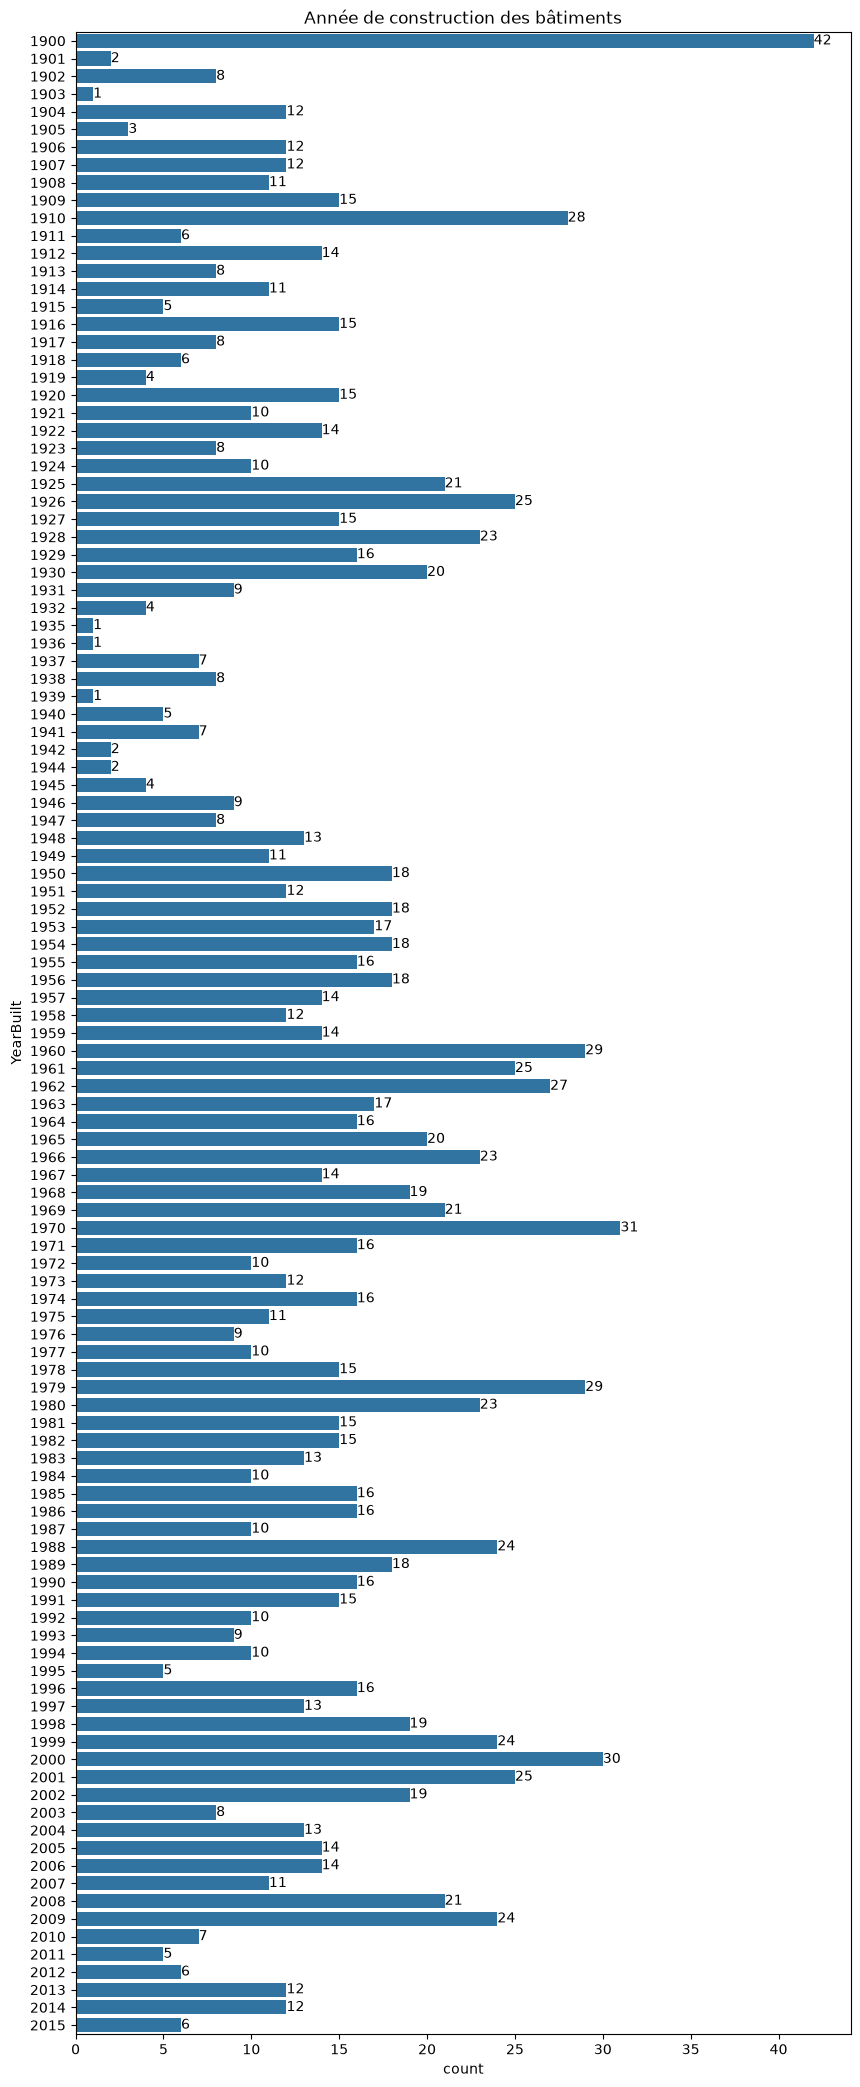

In [37]:
plt.figure(figsize=(10,26))
ax = sns.countplot(y=df_non_residentiel['YearBuilt'], data=df_non_residentiel)
ax.bar_label(ax.containers[0])
plt.title('Année de construction des bâtiments')
plt.show()

### Recherche des valeurs négatives

In [38]:
df_non_residentiel.min()

DataYear                                          2016
BuildingType                                    Campus
PrimaryPropertyType                Distribution Center
Latitude                                      47.49917
Longitude                                   -122.41182
YearBuilt                                         1900
NumberofBuildings                                  0.0
NumberofFloors                                       0
PropertyGFATotal                                 11285
PropertyGFAParking                                   0
PropertyGFABuilding(s)                            3636
ListOfAllPropertyUseTypes              Adult Education
LargestPropertyUseType                 Adult Education
LargestPropertyUseTypeGFA                       5656.0
SecondLargestPropertyUseType           Adult Education
SecondLargestPropertyUseTypeGFA                    0.0
ThirdLargestPropertyUseType                Bank Branch
ThirdLargestPropertyUseTypeGFA                     0.0
ENERGYSTAR

### Recherche des NaN dans la consommation d'énergie 

In [39]:
energies = [
    "Electricity(kBtu)",
    "NaturalGas(kBtu)",
    "SteamUse(kBtu)",
    "SiteEnergyUse(kBtu)",
    "SiteEnergyUseWN(kBtu)",
]
energies_presentes = [col for col in energies if col in df_non_residentiel.columns]

# Masque pour repérer les lignes ayant au moins un NaN dans les énergies
mask_nan = df_non_residentiel[energies_presentes].isna().any(axis=1)

# Filtrage du DataFrame
df_nan = df_non_residentiel[mask_nan].copy()

# Sélection des colonnes d'identité du bâtiment pour la lisibilité
cols_id = [
    c
    for c in ["BuildingTitle", "PropertyName", "PrimaryPropertyType"]
    if c in df_non_residentiel.columns
]

print("=" * 70)
print(f" NOMBRE DE BÂTIMENTS AVEC DES VALEURS MANQUANTES (NaN) : {len(df_nan)}")
print("=" * 70)

# Affichage des bâtiments concernés
display(df_nan[cols_id + energies_presentes])

 NOMBRE DE BÂTIMENTS AVEC DES VALEURS MANQUANTES (NaN) : 1


,PrimaryPropertyType,Electricity(kBtu),NaturalGas(kBtu),SteamUse(kBtu),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu)
549,Large Office,4871126.0,1416041.0,0.0,5177270.5,NaN


### On ne tient pas compte de ce type d'information 

In [40]:
df_non_residentiel = df_non_residentiel.drop (columns=['SiteEnergyUseWN(kBtu)'], errors='ignore') # Consommation d'énergie totale annuelle sur site, ajustée selon la météo.

### Recherche des valeurs négatives dans la consommation d'énergie kBtu et total emission

In [41]:
# Colonnes d'énergie à analyser
energies = [
    "Electricity(kBtu)",
    "NaturalGas(kBtu)",
    "SteamUse(kBtu)",
    "SiteEnergyUse(kBtu)",
    "TotalGHGEmissions",
]
energies_presentes = [col for col in energies if col in df_non_residentiel.columns]

# Identifiants du bâtiment pour l'affichage
cols_id = [
    c
    for c in ["BuildingType", "PrimaryPropertyType"]
    if c in df_non_residentiel.columns
]


# AFFICHAGE DES VALEURS NÉGATIVES UNIQUEMENT

mask_negatifs = pd.Series(False, index=df_non_residentiel.index)
for col in energies_presentes:
    mask_negatifs = mask_negatifs | (df_non_residentiel[col] < 0)

df_negatifs = df_non_residentiel[mask_negatifs].copy()

print("=" * 80)
print(
    f" BÂTIMENTS AVEC DES VALEURS NÉGATIVES (Total : {len(df_negatifs)})"
)
print("=" * 80)

if len(df_negatifs) > 0:
    display(df_negatifs[cols_id + energies_presentes])
else:
    print("Aucune valeur négative trouvée dans le jeu de données.\n")



 BÂTIMENTS AVEC DES VALEURS NÉGATIVES (Total : 0)
Aucune valeur négative trouvée dans le jeu de données.



### On élimine les lignes qui ont une consommation négatives sur toutes les énergies  ( dans le cas du traitement d'un autre fichier )

In [42]:
print(f"Nombre de bâtiments non résidentiels avant : {len(df_non_residentiel)}")
energies = [
    "Electricity(kBtu)",
    "NaturalGas(kBtu)",
    "SteamUse(kBtu)",
    "SiteEnergyUse(kBtu)",
    "TotalGHGEmissions",
]
energies_presentes = [col for col in energies if col in df_non_residentiel.columns]

df_non_residentiel = df_non_residentiel[ ( df_non_residentiel[energies_presentes] >= 0 ).all(axis=1) ]
print(f"Nombre de bâtiments non résidentiels après : {len(df_non_residentiel)}")

Nombre de bâtiments non résidentiels avant : 1543
Nombre de bâtiments non résidentiels après : 1543


### consommation par rapport à l'usage principal du batiment

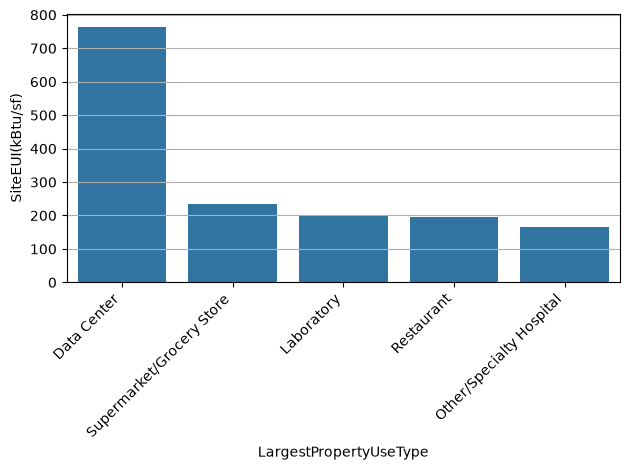

In [43]:
consommation_par_type = df_non_residentiel.groupby('LargestPropertyUseType')['SiteEUI(kBtu/sf)'].mean().sort_values(ascending=False).round(0).head(5)
sns.barplot(data=consommation_par_type)
plt.xticks(rotation=45, ha='right') 
plt.grid(axis='y')
plt.tight_layout()

### Affichage des batiments de type Data Center 

In [44]:
df_datacenter = df_non_residentiel[df_non_residentiel["LargestPropertyUseType"].str.contains( "Data Center" , case = False , na = False ) ]
display(df_datacenter)

,DataYear,BuildingType,PrimaryPropertyType,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,ENERGYSTARScoreIsMissing
233,2016,NonResidential,Other,47.66060,-122.31512,1969,1.0,5,36000,0,36000,Data Center,Data Center,36000.0,NaN,NaN,NaN,NaN,96.0,834.400024,834.400024,2620.000000,2620.000000,30038490.0,0.0,8803777.0,30038487.0,0.0,0.0,Compliant,209.41,0
1582,2016,NonResidential,Other,47.61449,-122.33956,1975,1.0,7,90679,35120,55559,"Data Center, Parking",Data Center,60000.0,Parking,30700.0,NaN,NaN,100.0,694.700012,694.700012,2181.300049,2181.300049,41680640.0,0.0,12215895.0,41680634.0,0.0,0.0,Compliant,290.57,0


### On élimine les Data Center qui peuvent influencer notre projet, gros consommateur d'énergie

In [45]:
print(f"Nombre de bâtiments non résidentiels avant : {len(df_non_residentiel)}")
df_non_residentiel = df_non_residentiel[~df_non_residentiel["LargestPropertyUseType"].str.contains( "Data Center" , case = False , na = False ) ]
print(f"Nombre de bâtiments non résidentiels après : {len(df_non_residentiel)}")

Nombre de bâtiments non résidentiels avant : 1543
Nombre de bâtiments non résidentiels après : 1541


### Vérification du nombre d'étage : NumberofFloors ( maximun est de 76 autorisé par la ville données sur le web)

In [46]:
df_non_residentiel['NumberofFloors'].describe()

count    1541.000000
mean        3.669046
std         5.416138
min         0.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        99.000000
Name: NumberofFloors, dtype: float64

In [47]:
nb_etage_diff =  df_non_residentiel ["NumberofFloors"].value_counts().sort_index()
print (nb_etage_diff )

NumberofFloors
0      10
1     448
2     375
3     257
4     137
5      91
6      73
7      29
8      15
9       8
10     16
11     16
12      7
13      7
14      7
15      6
16      2
17      3
18      2
19      3
20      2
21      1
22      2
23      3
24      3
25      2
29      3
33      1
34      1
36      2
37      1
39      1
41      1
42      3
47      1
63      1
99      1
Name: count, dtype: int64


In [48]:
df_99 =df_non_residentiel[ df_non_residentiel ["NumberofFloors"] == 99 ]
df_99.head() 

,DataYear,BuildingType,PrimaryPropertyType,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,ENERGYSTARScoreIsMissing
929,2016,NonResidential,Worship Facility,47.55072,-122.30265,1977,1.0,99,21948,0,21948,Worship Facility,Worship Facility,21948.0,NaN,NaN,NaN,NaN,80.0,14.9,14.9,46.599998,46.599998,326001.1875,0.0,95545.5,326001.0,0.0,0.0,Compliant,2.27,0


### On supprime la ligne vu comme une erreur de saisie

In [49]:
print(f"Nombre de bâtiments non résidentiels avant : {len(df_non_residentiel)}")
df_non_residentiel = df_non_residentiel[df_non_residentiel["NumberofFloors"] < 99]
print(f"Nombre de bâtiments non résidentiels après : {len(df_non_residentiel)}")

Nombre de bâtiments non résidentiels avant : 1541
Nombre de bâtiments non résidentiels après : 1540


### BoxPlots par surface et type

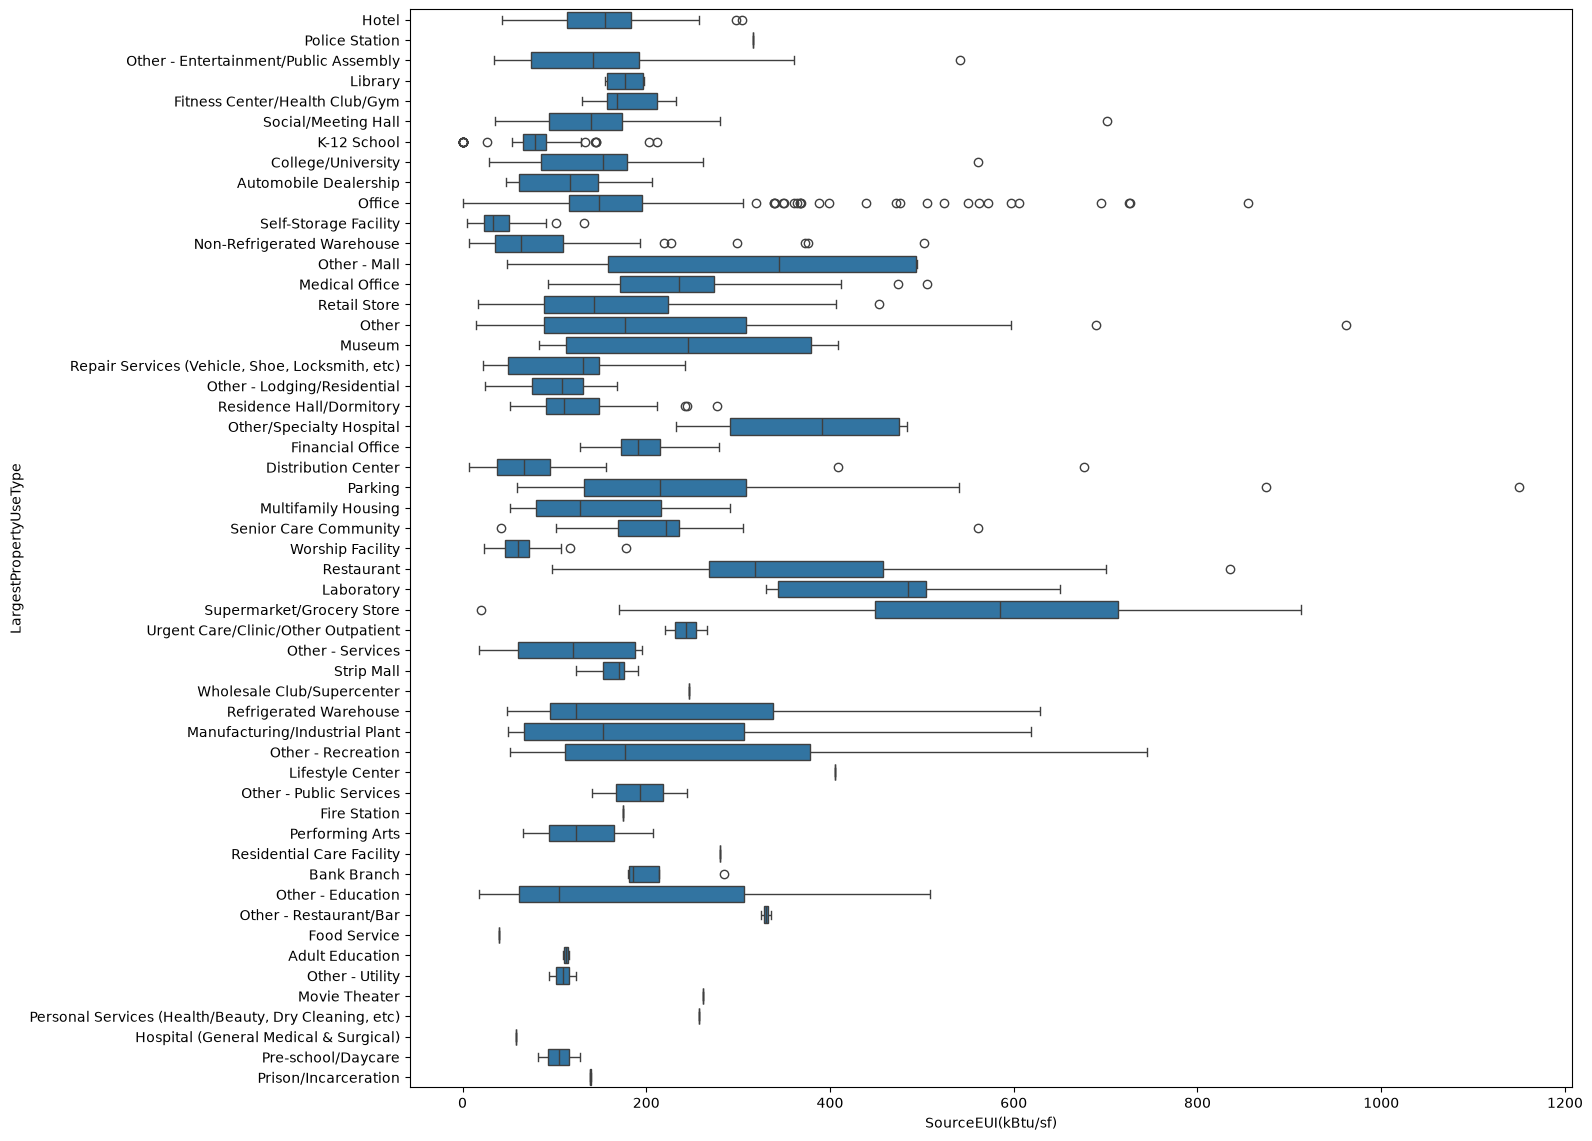

In [50]:
plt.figure (figsize=(15,14))
sns.boxplot(data=df_non_residentiel, x='SourceEUI(kBtu/sf)', y='LargestPropertyUseType')
plt.show()

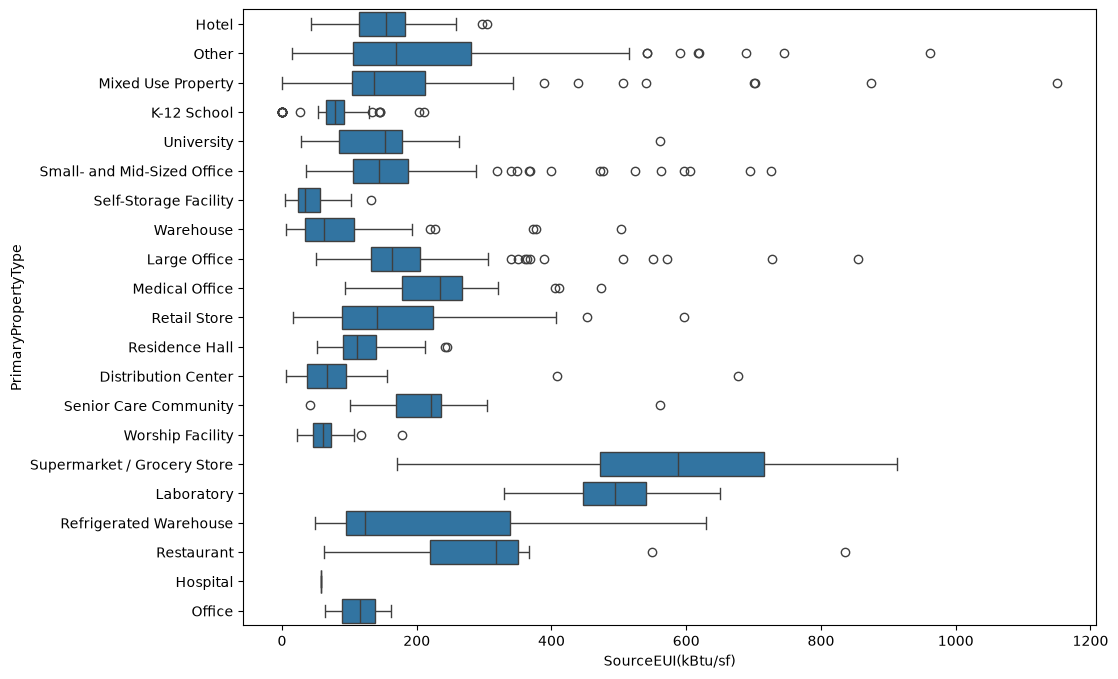

In [51]:
plt.figure (figsize=(11,8))
sns.boxplot(data=df_non_residentiel, x='SourceEUI(kBtu/sf)', y='PrimaryPropertyType')
plt.show()

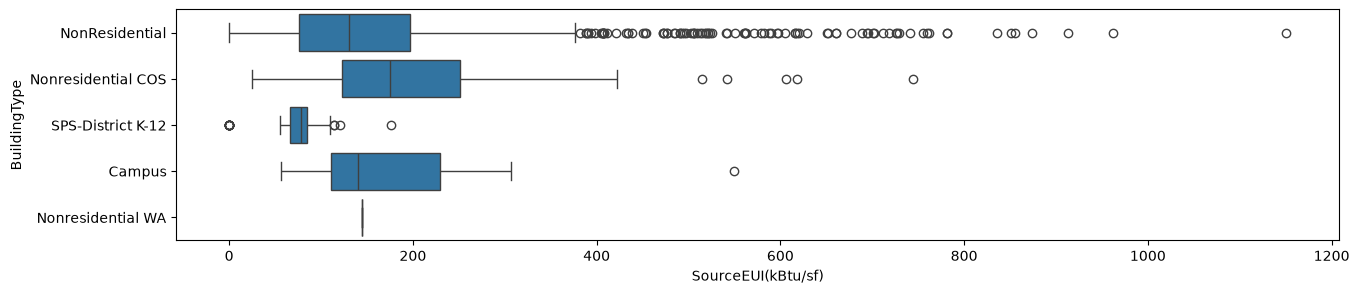

In [52]:
plt.figure (figsize=(15,3))
sns.boxplot(data=df_non_residentiel, x='SourceEUI(kBtu/sf)', y='BuildingType')
plt.show()

### Analyse des énergies sous forme graphiques

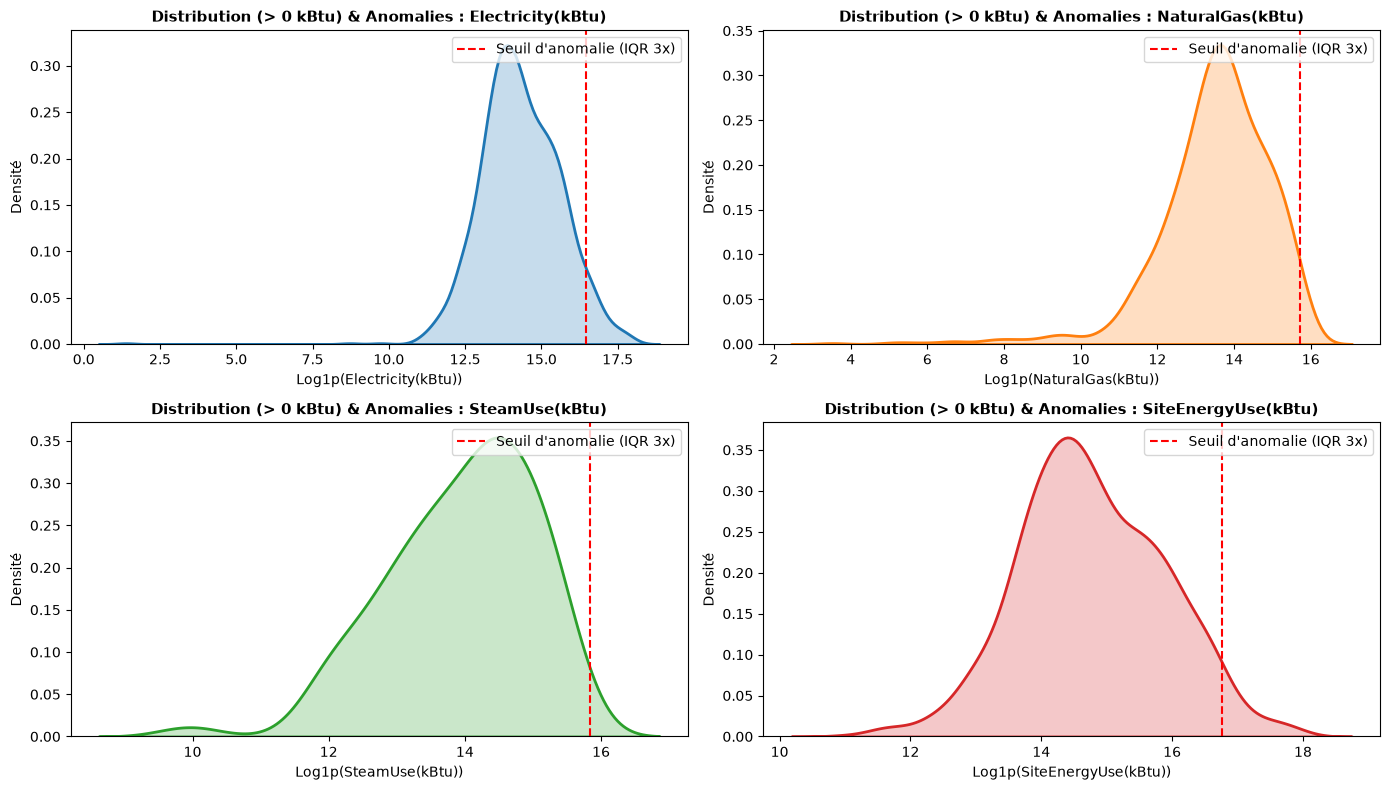

 NOMBRE TOTAL DE BÂTIMENTS PRÉSENTANT DES ANOMALIES : 104


,LargestPropertyUseType,PrimaryPropertyType,Electricity(kBtu),NaturalGas(kBtu),SteamUse(kBtu),SiteEnergyUse(kBtu)
465,Parking,Mixed Use Property,63822136.0,13053.0,0.0000,63835192.0
184,Other,Other,62197171.0,0.0,0.0000,62197176.0
226,Office,Large Office,61576180.0,0.0,0.0000,61576184.0
480,Office,Large Office,55123924.0,388532.0,986403.1875,56498868.0
301,Parking,Mixed Use Property,53506520.0,1566594.0,0.0000,55073120.0
...,...,...,...,...,...,...
920,Laboratory,Laboratory,4675400.0,7340535.0,0.0000,12015936.0
172,Hotel,Hotel,3561742.0,8373976.0,0.0000,11935719.0
92,K-12 School,K-12 School,3926011.0,7839670.0,0.0000,11765682.0
604,Other,Other,4031128.0,7116213.0,0.0000,11147342.0


In [53]:
energies = [
    "Electricity(kBtu)",
    "NaturalGas(kBtu)",
    "SteamUse(kBtu)",
    "SiteEnergyUse(kBtu)",
]
energies_presentes = [col for col in energies if col in df_non_residentiel.columns]

# ==============================================================================
# 1. DÉTECTION STATISTIQUE (Calculé UNIQUEMENT sur les valeurs > 0)
# ==============================================================================
anomalies_mask = pd.Series(False, index=df_non_residentiel.index)
seuils = {}

for col in energies_presentes:
    # On isole les valeurs strictement positives pour calculer les quartiles réels
    valeurs_positives = df_non_residentiel[df_non_residentiel[col] > 0][col]

    # Détection des négatifs sur tout le jeu de données
    is_neg = df_non_residentiel[col] < 0

    if len(valeurs_positives) > 0:
        Q1 = valeurs_positives.quantile(0.25)
        Q3 = valeurs_positives.quantile(0.75)
        IQR = Q3 - Q1
        seuil_haut = Q3 + 3 * IQR
        seuils[col] = seuil_haut

        is_outlier = df_non_residentiel[col] > seuil_haut
    else:
        seuils[col] = np.nan
        is_outlier = pd.Series(False, index=df_non_residentiel.index)

    # Masque global des anomalies
    anomalies_mask = anomalies_mask | is_neg | is_outlier

# ==============================================================================
# 2. VISUALISATION KDE (Uniquement pour les consommations > 0)
# ==============================================================================
plt.figure(figsize=(14, 8))
couleurs = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for i, (col, color) in enumerate(zip(energies_presentes, couleurs), 1):
    plt.subplot(2, 2, i)

    # CORRECTION : On filtre uniquement les valeurs > 0 pour le graphique
    data_positives = df_non_residentiel[df_non_residentiel[col] > 0][col]

    if len(data_positives) > 0:
        # Transformation log1p sur les données positives uniquement
        data_log = np.log1p(data_positives)

        # Courbe de densité
        sns.kdeplot(data_log, fill=True, color=color, linewidth=2)

        # Ligne verticale du seuil
        if not np.isnan(seuils[col]):
            seuil_log = np.log1p(seuils[col])
            plt.axvline(
                x=seuil_log,
                color="red",
                linestyle="--",
                linewidth=1.5,
                label="Seuil d'anomalie (IQR 3x)",
            )

        plt.title(
            f"Distribution (> 0 kBtu) & Anomalies : {col}",
            fontsize=11,
            fontweight="bold",
        )
        plt.xlabel(f"Log1p({col})")
        plt.ylabel("Densité")
        plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

# ==============================================================================
# 3. EXTRACTION ET AFFICHAGE DES ANOMALIES
# ==============================================================================
df_anomalies = df_non_residentiel[anomalies_mask].copy()

cols_identite = [
    c
    for c in ["LargestPropertyUseType", "PropertyName", "PrimaryPropertyType"]
    if c in df_non_residentiel.columns
]
cols_a_afficher = cols_identite + energies_presentes

print("=" * 80)
print(f" NOMBRE TOTAL DE BÂTIMENTS PRÉSENTANT DES ANOMALIES : {len(df_anomalies)}")
print("=" * 80)

display(
    df_anomalies[cols_a_afficher].sort_values(
        by=energies_presentes[-1], ascending=False
    )
)

Pour exploiter la typologie des consommations sans introduire de fuite de données via les volumes consommés, 
des variables ratio de consommation (Électricité, Gaz, Vapeur).
 Ces variables permettent au modèle d'intégrer l'impact du mix énergétique du bâtiment sur les émissions de CO2.

In [54]:
# Calcul de la consommation totale des 3 énergies en kBtu
total_energy = (
    df_non_residentiel["Electricity(kBtu)"].fillna(0)
    + df_non_residentiel["NaturalGas(kBtu)"].fillna(0)
    + df_non_residentiel["SteamUse(kBtu)"].fillna(0)
)

# Part de chaque énergie 
df_non_residentiel["Ratio_Electricity"] = (
    df_non_residentiel["Electricity(kBtu)"].fillna(0) / total_energy
).fillna(0)
df_non_residentiel["Ratio_Gas"] = (
    df_non_residentiel["NaturalGas(kBtu)"].fillna(0) / total_energy
).fillna(0)
df_non_residentiel["Ratio_Steam"] = (
    df_non_residentiel["SteamUse(kBtu)"].fillna(0) / total_energy
).fillna(0)

# on vérifie que les df ont le même nombre de ligne pour suppression de lignes
print(f"Nombre de lignes df_non_residentiel : {len(df_non_residentiel)}")
print(f"Nombre de lignes building_consumption : {len(building_consumption)}")

Nombre de lignes df_non_residentiel : 1540
Nombre de lignes building_consumption : 1543


In [55]:
print (f"Nombre de colonnes avant : {len(df_non_residentiel.columns)}")
# on supprime tous les types de style consommation après cacul du ratio
cols_to_remove = [
    "SiteEnergyUse(kBtu)",
    "SiteEnergyUseWN(kBtu)",
    "Electricity(kWh)",
    "Electricity(kBtu)",
    "NaturalGas(therms)",
    "NaturalGas(kBtu)",
    "SteamUse(kBtu)",
    "SiteEUI(kBtu/sf)",
    "SiteEUIWN(kBtu/sf)",
    "SourceEUI(kBtu/sf)",
    "SourceEUIWN(kBtu/sf)",

]

df_non_residentiel = df_non_residentiel.drop (columns=cols_to_remove, errors='ignore').reset_index(drop=True)
print (f"Nombre de colonnes après : {len(df_non_residentiel.columns)}")

Nombre de colonnes avant : 35
Nombre de colonnes après : 25


## Enrichir le jeu de données actuel avec de nouvelles features Engineering issues de celles existantes. 

Les colonnes suivantes sont exclue (redondance spaciale )

In [56]:
print (f"Nombre de colonnes avant : {len(df_non_residentiel.columns)}")
df_non_residentiel = df_non_residentiel.drop (columns=['SecondLargestPropertyUseType'], errors='ignore').reset_index(drop=True)
df_non_residentiel = df_non_residentiel.drop (columns=['SecondLargestPropertyUseTypeGFA'], errors='ignore').reset_index(drop=True)
df_non_residentiel = df_non_residentiel.drop (columns=['ThirdLargestPropertyUseType'], errors='ignore').reset_index(drop=True)
df_non_residentiel = df_non_residentiel.drop (columns=['ThirdLargestPropertyUseTypeGFA'], errors='ignore').reset_index(drop=True)
print (f"Nombre de colonnes après : {len(df_non_residentiel.columns)}")

Nombre de colonnes avant : 25
Nombre de colonnes après : 21


### Calcul de l'age du bâtiment au moment de la mesure

In [57]:
print (f"Nombre de colonnes avant : {len(df_non_residentiel.columns)}")

df_non_residentiel["BuildingAge"] = df_non_residentiel["DataYear"] - df_non_residentiel["YearBuilt"]
# Suppression de la colonne YearBuilt année de construction redondance
df_non_residentiel = df_non_residentiel.drop(columns=["YearBuilt"])
print (f"Nombre de colonnes aprés ajout et supression : {len(df_non_residentiel.columns)}")

Nombre de colonnes avant : 21
Nombre de colonnes aprés ajout et supression : 21


### Calcul de la moyenne de surface par étage 

In [58]:
print (f"Nombre de colonnes avant : {len(df_non_residentiel.columns)}")
df_non_residentiel['mean_GFA_per_floor'] = df_non_residentiel['PropertyGFABuilding(s)'] / (df_non_residentiel['NumberofFloors'] + 1)
# suppression redondance
df_non_residentiel = df_non_residentiel.drop(columns=["NumberofFloors"])
print (f"Nombre de colonnes après : {len(df_non_residentiel.columns)}")


Nombre de colonnes avant : 21
Nombre de colonnes après : 21


### Nombre d'usages différents dans le batiment :Diversité fonctionnelle

In [59]:

def count_unique_uses(text):
    # Si la valeur est absente ou vaut 'nan'
    if pd.isna(text) or str(text).strip().lower() in ["nan", ""]:
        return 1
    items = str(text).split(",")
    # Nettoyage : on enlève les espaces vides autour de chaque mot et on filtre les éléments vides
    cleaned_items = [item.strip() for item in items if item.strip()]    
    # Compter les éléments uniques (en casde doublons de saisie)
    return len(set(cleaned_items)) if cleaned_items else 1

#  extraction sur la colonne ListOfAllPropertyUseTypes
df_non_residentiel["Number_of_Use_Types"] = df_non_residentiel["ListOfAllPropertyUseTypes"].apply(count_unique_uses)
print (f"Nombre de colonnes aprés ajout : {len(df_non_residentiel.columns)}")

Nombre de colonnes aprés ajout : 22


In [60]:
# suppression de la colonne
df_non_residentiel = df_non_residentiel.drop(columns=["ListOfAllPropertyUseTypes"], errors='ignore')
print(f"Nombre final de colonnes dans df_non_residentiel : {df_non_residentiel.shape[1]}")

Nombre final de colonnes dans df_non_residentiel : 21


<Axes: >

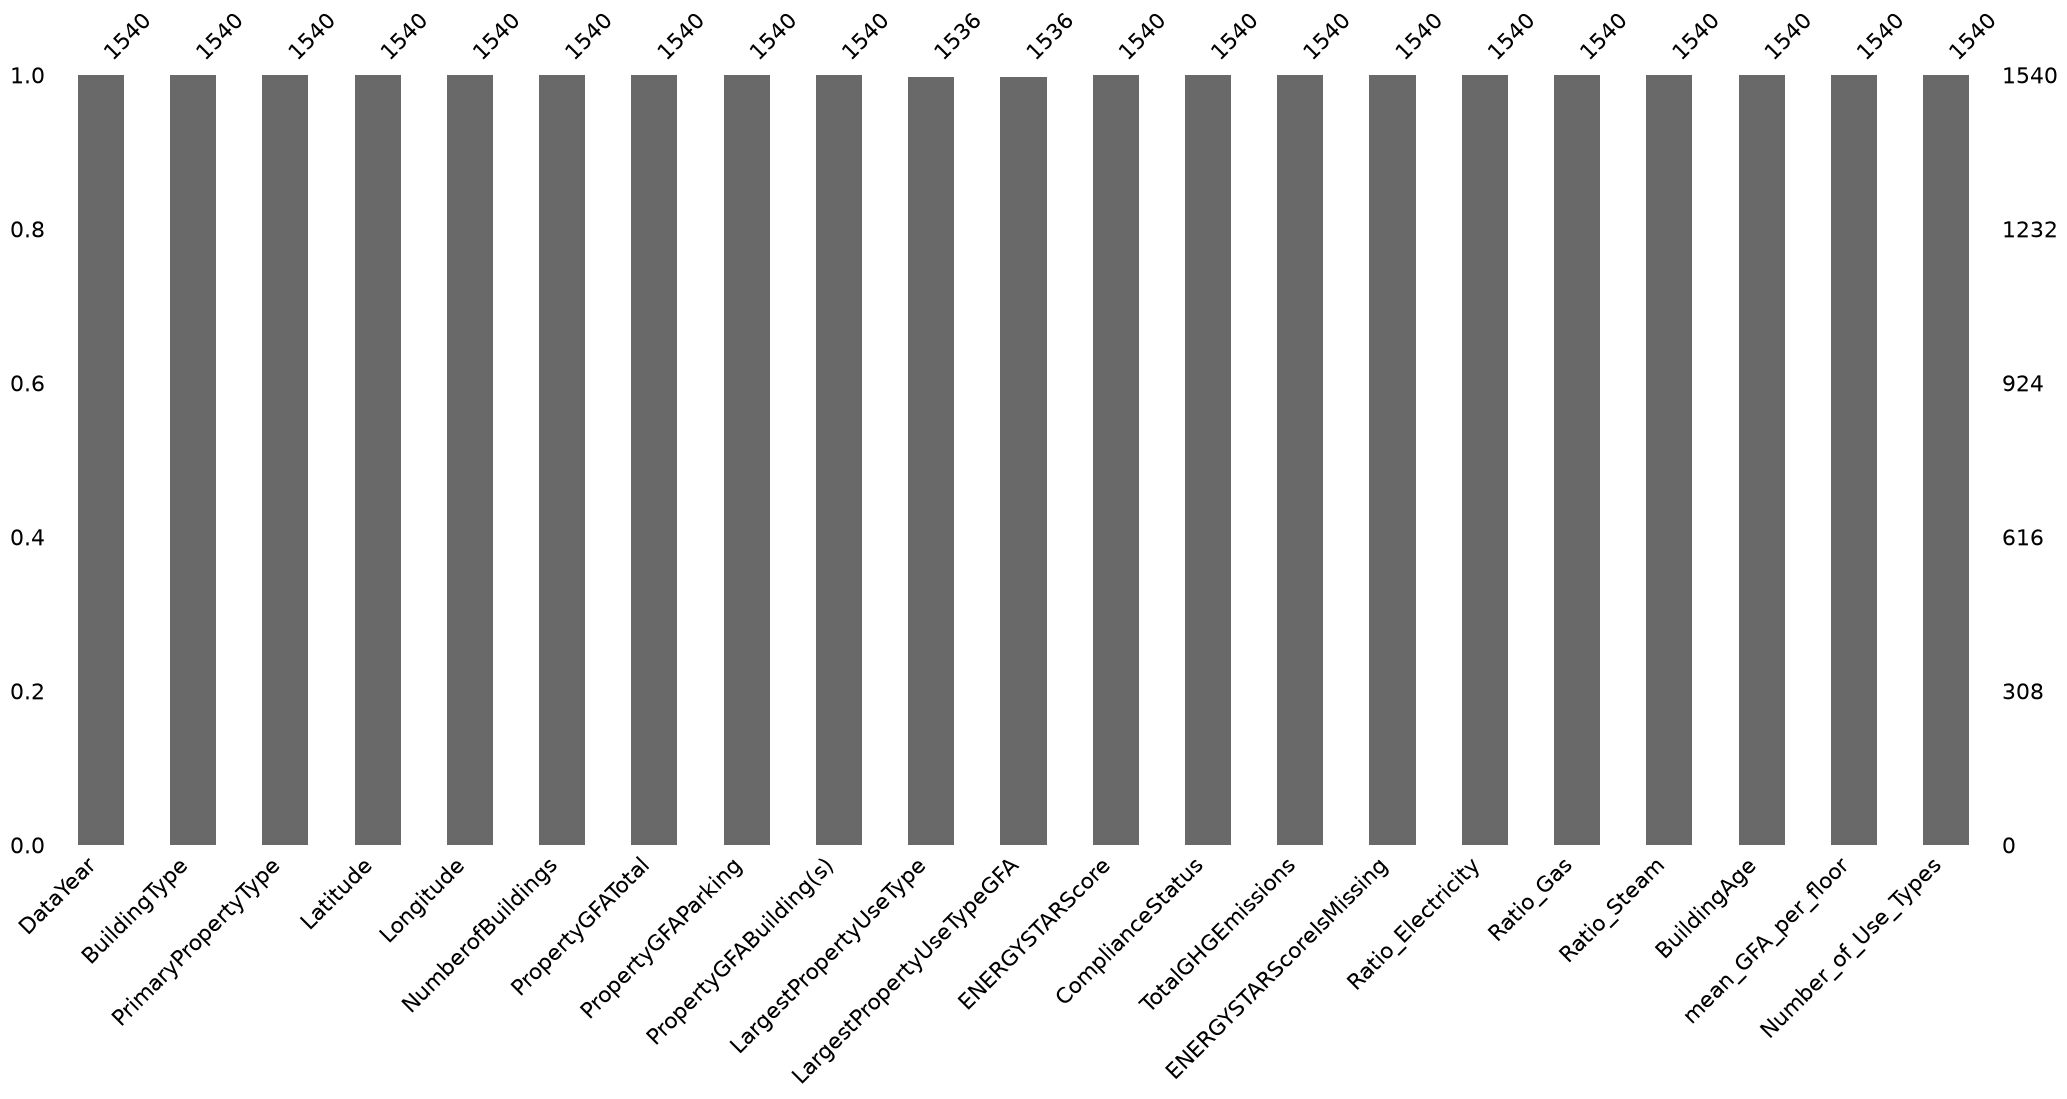

In [61]:
msno.bar(df_non_residentiel)

On remarque des valeurs manquantes pour la colonne : largest_property_use_type et GFA

In [62]:
# Compter le nombre de lignes avec un NaN
nb_nan = df_non_residentiel["LargestPropertyUseType"].isna().sum()
pct_nan = (nb_nan / len(df_non_residentiel)) * 100

print(f"Nombre de lignes avec NaN dans LargestPropertyUseType : {nb_nan}")
print(f"Cela représente : {pct_nan:.2f}% du jeu de données\n")

Nombre de lignes avec NaN dans LargestPropertyUseType : 4
Cela représente : 0.26% du jeu de données



In [63]:
# Affiche les lignes concernées 
colonnes_observation = [
    "PrimaryPropertyType",
    "LargestPropertyUseType",
    "LargestPropertyUseTypeGFA",
    "PropertyGFATotal",
    "TotalGHGEmissions",
]

# Affichage des bâtiments ayant la valeur manquante
df_non_residentiel[df_non_residentiel["LargestPropertyUseType"].isna()][colonnes_observation]

,PrimaryPropertyType,LargestPropertyUseType,LargestPropertyUseTypeGFA,PropertyGFATotal,TotalGHGEmissions
288,Self-Storage Facility,NaN,NaN,111445,163.83
735,Hotel,NaN,NaN,61721,36.92
1243,Small- and Mid-Sized Office,NaN,NaN,48350,22.09
1260,Restaurant,NaN,NaN,28800,29.21


Après analyse , on supprime les NaN  en constatant une diminution de R2 ( ci-dessous le code en commentaire tester )

In [64]:
#df_non_residentiel["LargestPropertyUseType"] = df_non_residentiel["LargestPropertyUseType"].fillna (df_non_residentiel["PrimaryPropertyType"] )

In [65]:
#df_non_residentiel["LargestPropertyUseTypeGFA"] = df_non_residentiel["LargestPropertyUseTypeGFA"].fillna (df_non_residentiel["PropertyGFATotal"] )

In [66]:
#print (f"Nombre de lignes avant : {len(df_non_residentiel)}")
df_non_residentiel = df_non_residentiel.dropna(subset=["LargestPropertyUseType"] ).reset_index(drop = True)
# on vérifie que les df ont le même nombre de ligne pour suppression de lignes
print(f"Nombre de lignes df_non_residentiel : {len(df_non_residentiel)}")

Nombre de lignes df_non_residentiel : 1536


###  Matrice de corrélation

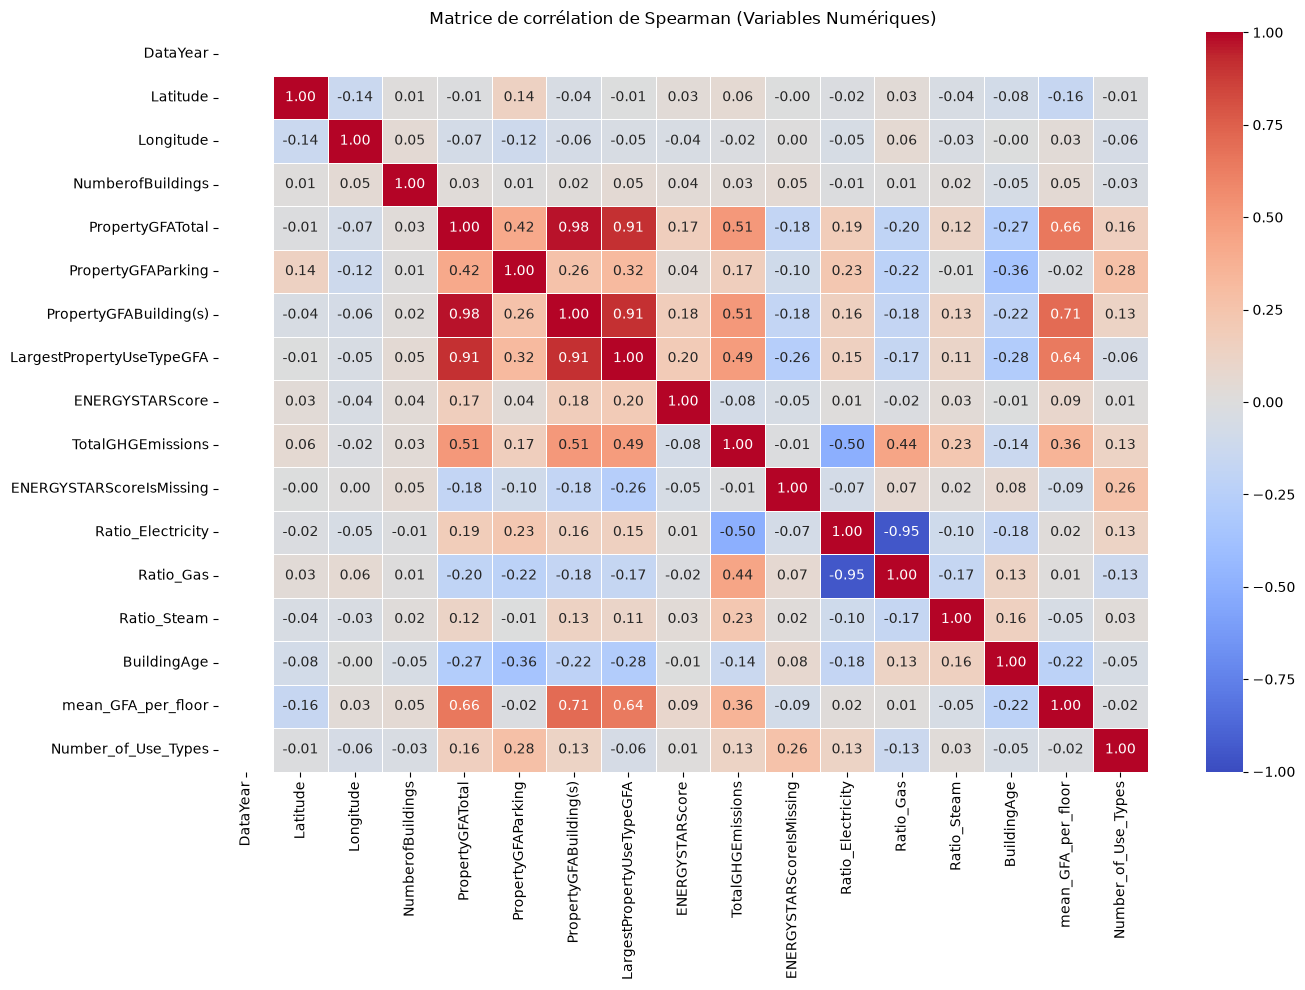

In [67]:
# Sélection des colonnes numériques
num_cols = df_non_residentiel.select_dtypes(include=[np.number]).columns

# Calcul de la matrice de corrélation (Spearman est idéal pour les distributions étirées)
corr_matrix = df_non_residentiel[num_cols].corr(method="spearman")

# 3. Affichage de la Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title("Matrice de corrélation de Spearman (Variables Numériques)")
plt.tight_layout()
plt.show()

### Gestion de données de la matrice 

In [68]:

print (f"Nombre de colonnes avant : {len(df_non_residentiel.columns)}")
# Calcul de la matrice en valeur absolue 
corr_abs = corr_matrix.abs()

# Sélection de la partie supérieure de la matrice (pour éviter la diagonale et les doublons)
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

# Identification des colonnes ayant une corrélation > 0.85 avec une autre
#  Corrélation (|r|) :
#  [ 0.00 ............  0.50 ............  0.85  ............  1.00 ]
#  <--- Utile / Indépendant ---> | <--- Multi-colinéarité sévère ---> (0.70 à 0.85 zone grise à modifier si instabilité)
#                                   (Zone de suppression)
seuil = 0.85 
colonnes_a_supprimer = [
    column for column in upper.columns if any(upper[column] > seuil)
]

print(f"Colonnes redondantes identifiées ({len(colonnes_a_supprimer)}) :")
print(colonnes_a_supprimer)

# Suppression des colonnes redondantes dans le DataFrame : df_non_residentiel
df_non_residentiel = df_non_residentiel.drop(columns=colonnes_a_supprimer)
print (f"Nombre de colonnes après : {len(df_non_residentiel.columns)}")

Nombre de colonnes avant : 21
Colonnes redondantes identifiées (3) :
['PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA', 'Ratio_Gas']
Nombre de colonnes après : 18


Valeurs estimées
Dans un premier temps on ne tient pas compte de ses valeurs ( on vérifira l'estimation ultérieurement )
On enregistre les valeurs supprimées dans un data frame de test : df_esti , cela
nous permettra de vérifier la justesse de l'estimation après vérification de toutes les étapes de 
notre modèle ML

In [69]:
# calcul en % le taux de valeurs estimées
df_non_residentiel["ComplianceStatus"].value_counts(normalize=True)*100



ComplianceStatus
Compliant                       93.750000
Error - Correct Default Data     5.533854
Missing Data                     0.716146
Name: proportion, dtype: float64

In [70]:

df_esti = df_non_residentiel[df_non_residentiel["ComplianceStatus"] != "Compliant"].reset_index(drop=True)
print(f"Nombre de lignes estimées concernées : {len(df_esti)}")

Nombre de lignes estimées concernées : 96


In [71]:
print (f"Nombre total de lignes avant : {len(df_non_residentiel)}")
df_non_residentiel = df_non_residentiel[df_non_residentiel["ComplianceStatus"] == "Compliant"].reset_index(drop=True)
building_consumption = building_consumption[building_consumption["ComplianceStatus"] == "Compliant"].reset_index(drop=True)

# on supprime la colonne ComplianceStatus qui ne sera plus utile
df_non_residentiel = df_non_residentiel.drop (columns=['ComplianceStatus'], errors='ignore')
df_esti = df_esti.drop (columns=['ComplianceStatus'], errors='ignore')

print(f"Nombre de bâtiments conservés après suppression des estimations: {len(df_non_residentiel)}")
print(f"Nombre de bâtiments estimés: {len(df_esti)}")
print(f"Nombre de lignes building_consumption : {len(building_consumption)}")

Nombre total de lignes avant : 1536
Nombre de bâtiments conservés après suppression des estimations: 1440
Nombre de bâtiments estimés: 96
Nombre de lignes building_consumption : 1447


# Visualise les colonnes restantes

In [72]:
df_non_residentiel.info()

<class 'pandas.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   DataYear                  1440 non-null   int64  
 1   BuildingType              1440 non-null   str    
 2   PrimaryPropertyType       1440 non-null   str    
 3   Latitude                  1440 non-null   float64
 4   Longitude                 1440 non-null   float64
 5   NumberofBuildings         1440 non-null   float64
 6   PropertyGFATotal          1440 non-null   int64  
 7   PropertyGFAParking        1440 non-null   int64  
 8   LargestPropertyUseType    1440 non-null   str    
 9   ENERGYSTARScore           1440 non-null   float64
 10  TotalGHGEmissions         1440 non-null   float64
 11  ENERGYSTARScoreIsMissing  1440 non-null   int64  
 12  Ratio_Electricity         1440 non-null   float64
 13  Ratio_Steam               1440 non-null   float64
 14  BuildingAge        

### analyse univariée sur toutes les variables  float64 & int64

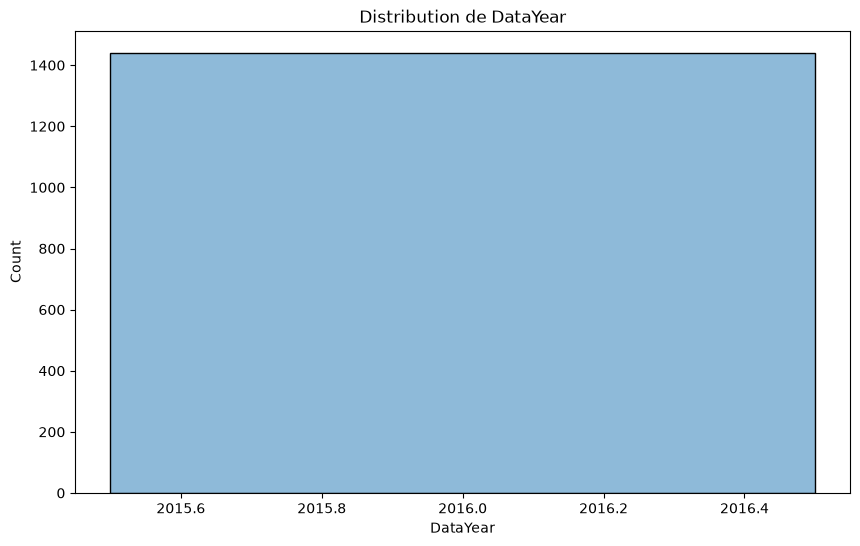

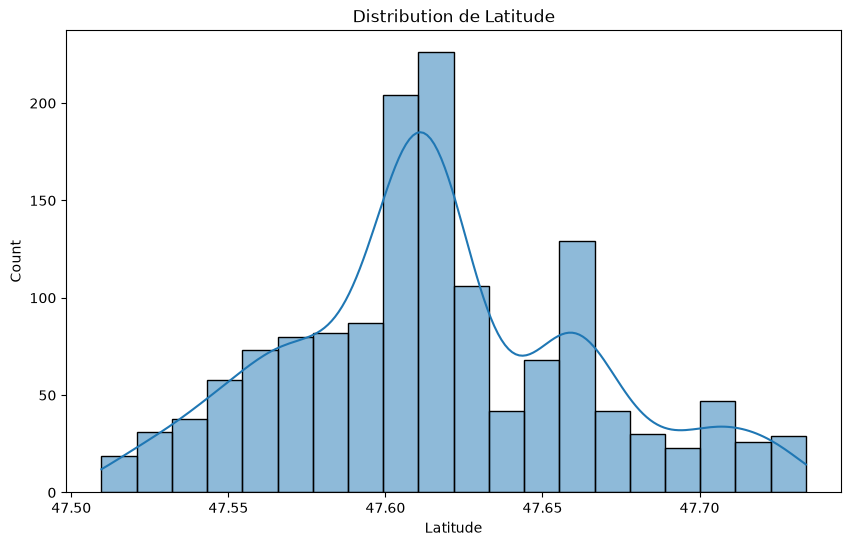

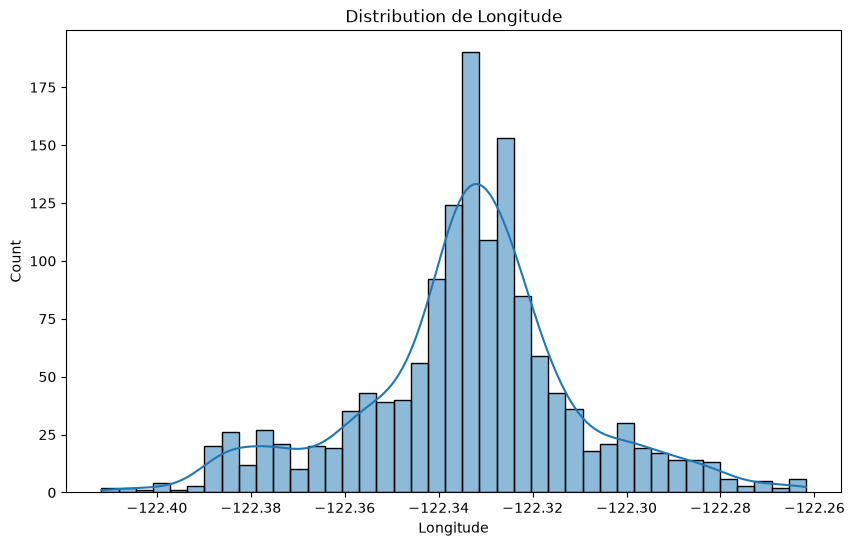

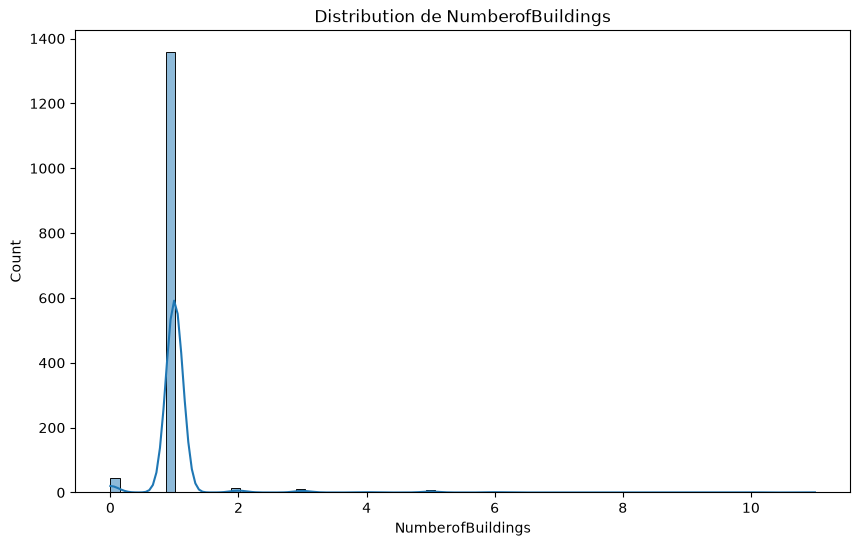

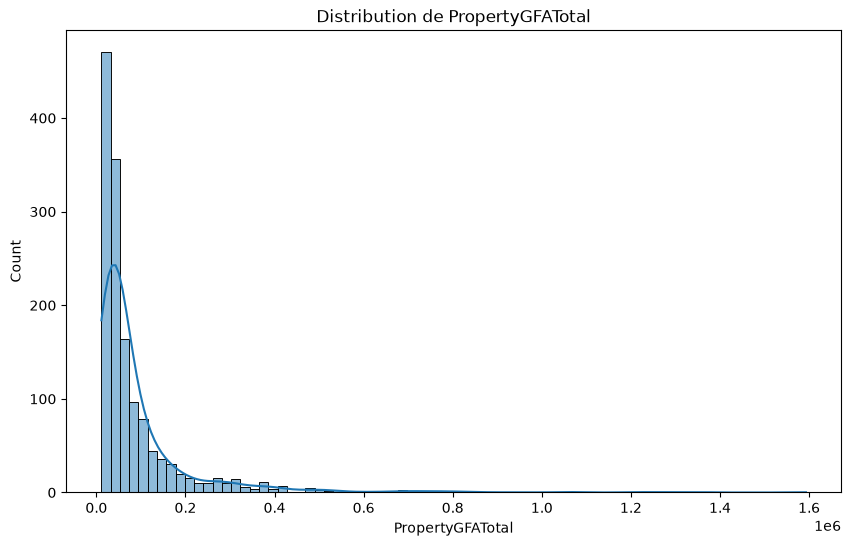

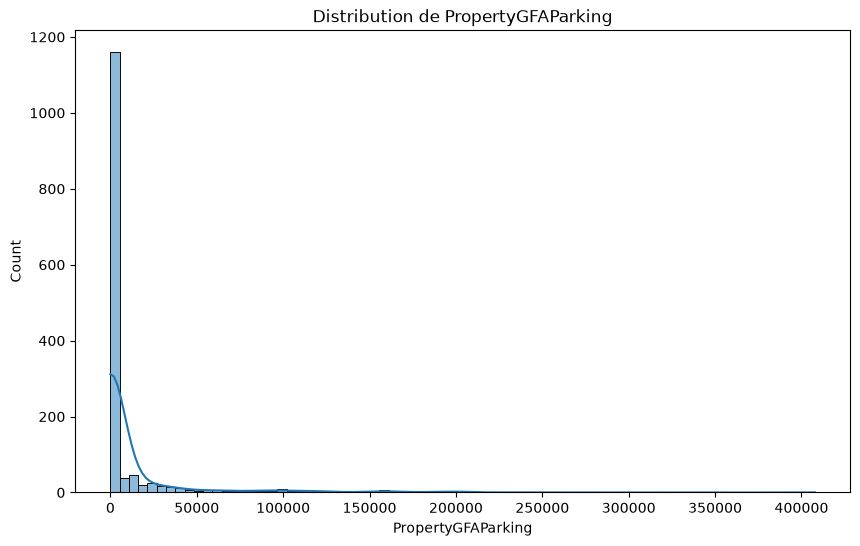

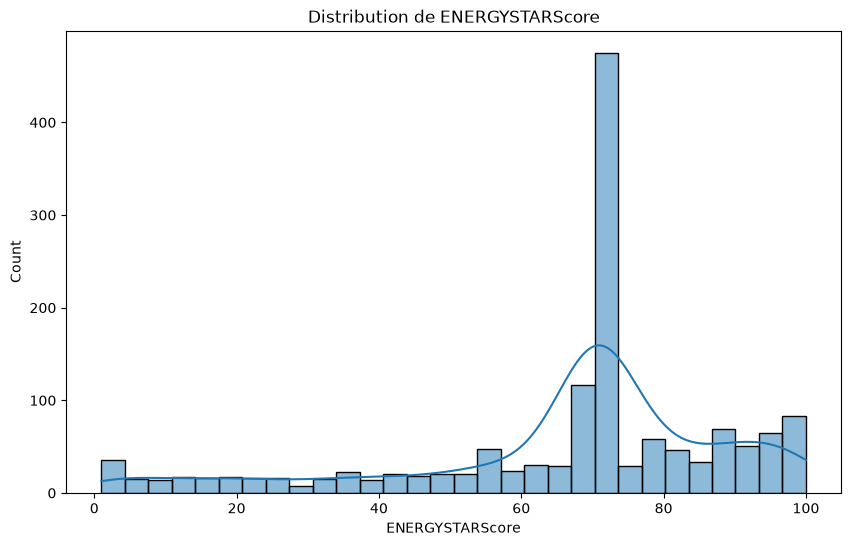

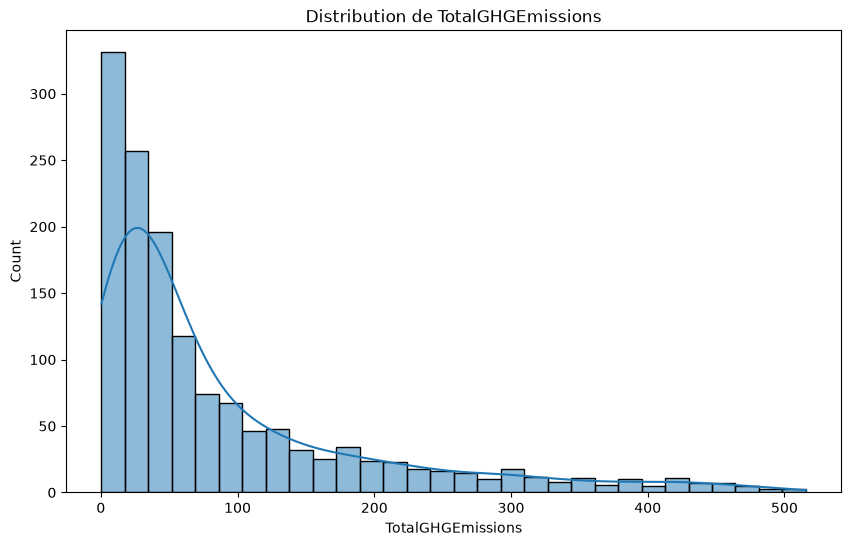

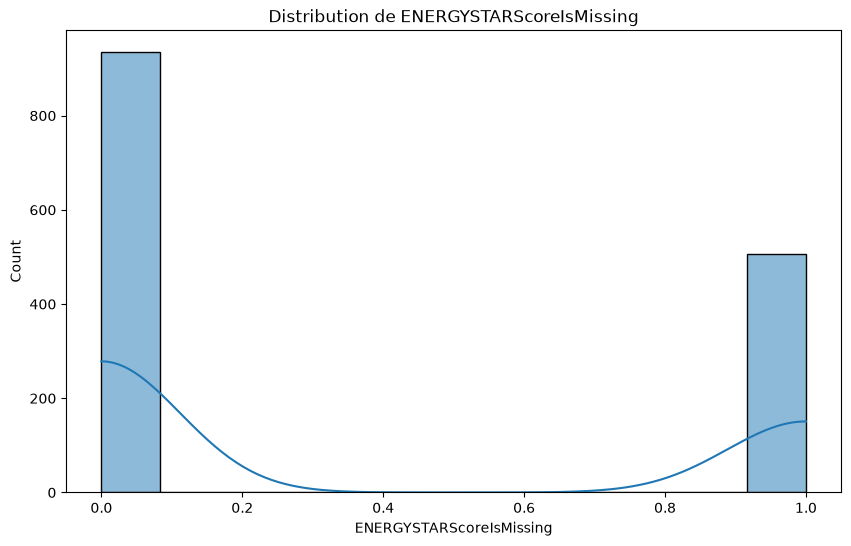

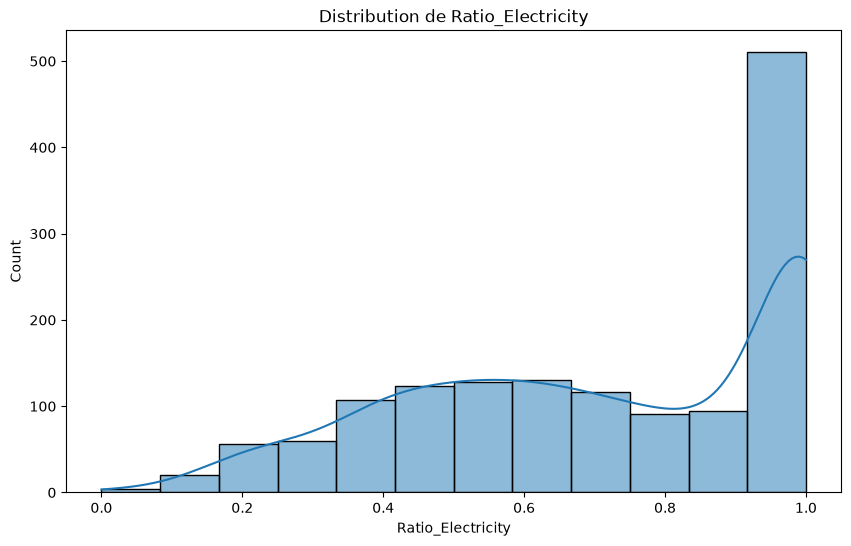

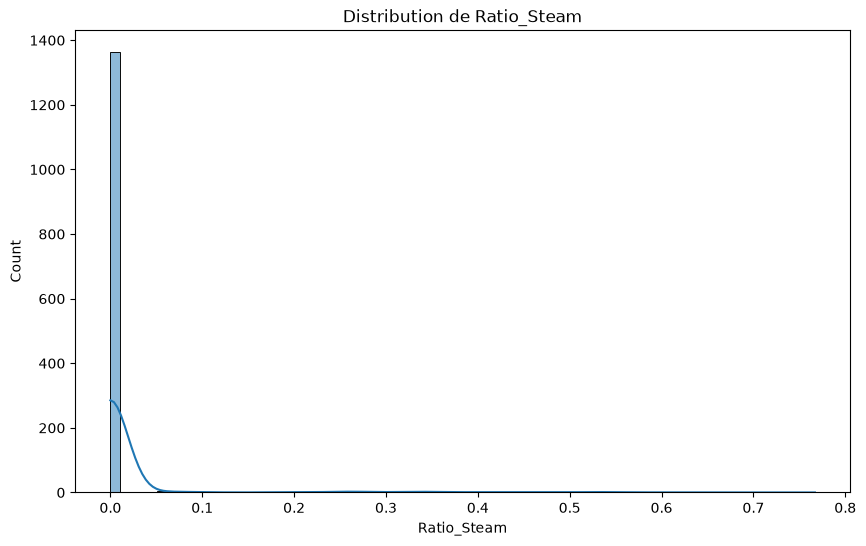

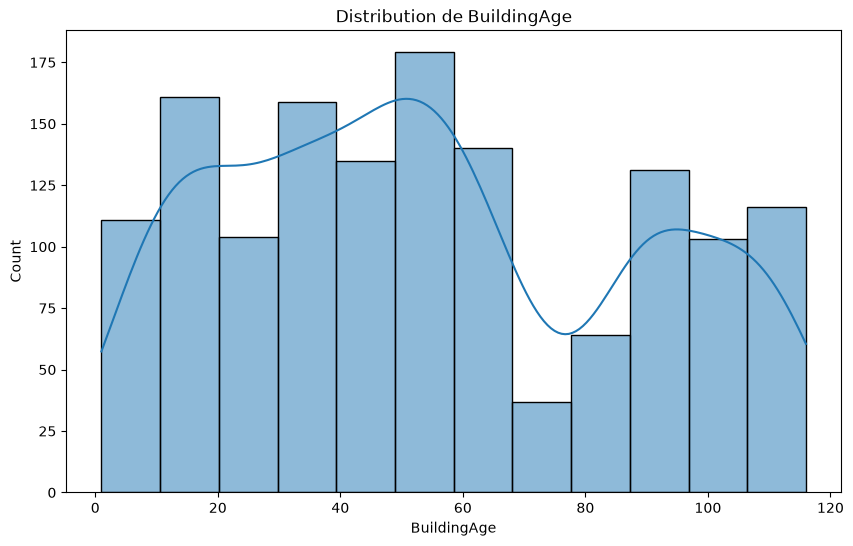

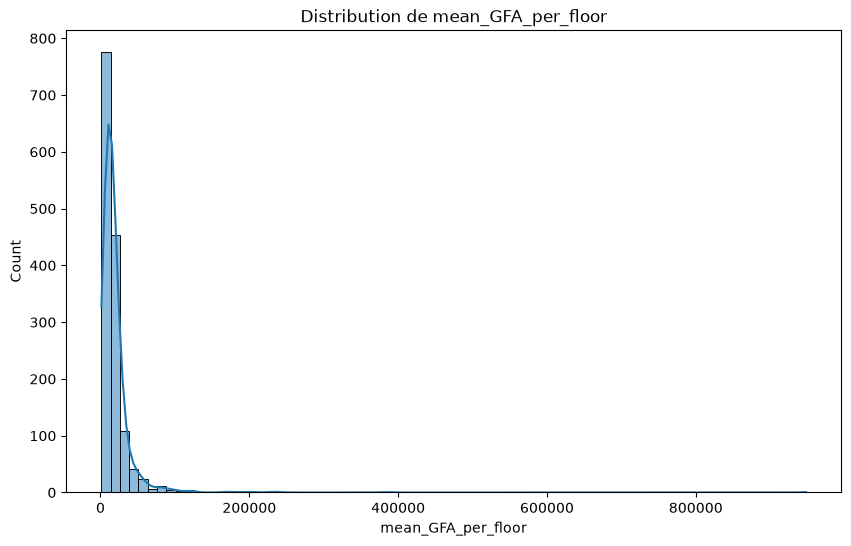

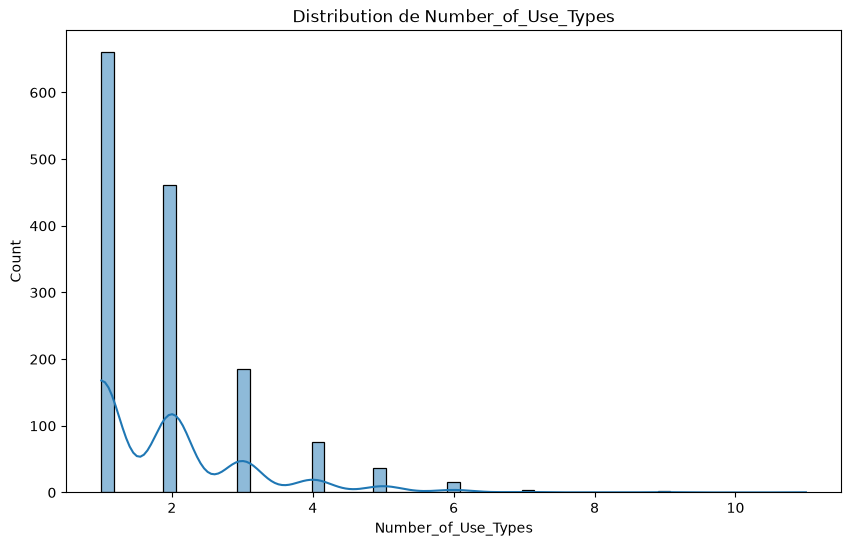

In [73]:
for column in df_non_residentiel.select_dtypes(['int64','float64']).columns:
    plt.figure(figsize=(10,6))
    plt.title('Distribution de ' + column)
    sns.histplot(df_non_residentiel[column], kde = True)
    plt.show()

### sauvegarde de l'analyse

In [74]:
# on supprime la colonne ENERGYSTARScore , on met en commentaire les résultats modifient les scores ML
#df_non_residentiel = df_non_residentiel.drop (columns=['ENERGYSTARScore'], errors='ignore')
#df_esti = df_esti.drop (columns=['ENERGYSTARScore'], errors='ignore')

In [75]:
df_non_residentiel.to_csv('./data/projet6_analyse.csv', index = False); # mettre false pour le ML

### sauvegarde des données estimées


In [76]:
df_esti.to_csv('./data/projet6_estimation.csv', index = False)

### On enregistre avec les colonnes ordonnés
### pour une meilleure lisibilité lors de l'utilisation au format ML
### avec l'interface web port 3000 

In [77]:

col_util = [
    "DataYear" ,
    "BuildingAge" ,
    "BuildingType" ,
    "PrimaryPropertyType" ,
    "LargestPropertyUseType" ,
    "Latitude" ,
    "Longitude" ,
    "NumberofBuildings" ,
    "PropertyGFATotal" ,
    "PropertyGFAParking" ,
    "mean_GFA_per_floor" ,
    "Number_of_Use_Types" ,
    "ENERGYSTARScore" ,
    "ENERGYSTARScoreIsMissing" ,
    "Ratio_Electricity",
    "Ratio_Steam"
]


# json pour le test par batiment

In [78]:
num_lig =1
df_esti["TotalGHGEmissions"].head(num_lig) # affichage de la conso estimée

0    38.53
Name: TotalGHGEmissions, dtype: float64

In [79]:

df_filtered = df_esti[col_util].head(num_lig) # numéro de ligne choisi
# Conversion en dictionnaire et ajout de la clé "input_data"
building_data = df_filtered.to_dict(orient="records")[0]
payload = {"input_data": building_data}
# Sauvegarde dans le fichier JSON
with open("./data/building_sample.json", "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2)

print("Fichier building_sample.json créé ")    

Fichier building_sample.json créé 
